# Credit Risk Prediction & ML Model Monitoring Pipeline

In [1]:
# Credit Risk Prediction & ML Model Monitoring Pipeline

print("Credit Risk ML Pipeline")
print("Environment is ready.")

Credit Risk ML Pipeline
Environment is ready.


## 1. Environment & Library Setup

### 1.1 Import Required Libraries

This section imports the Python libraries required for data processing, visualization, scalable Spark processing, machine learning, experiment tracking, and model evaluation.

In [47]:
# Core Python libraries
import os
import random
import warnings
from pathlib import Path

# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# PySpark
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

# Machine Learning
from sklearn.pipeline import Pipeline

# Suppress non-critical warnings
warnings.filterwarnings("ignore")

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

print("All required libraries imported successfully.")

All required libraries imported successfully.


### 1.2 Set Reproducibility

A fixed random seed ensures that randomized operations such as data splitting, model training, and sampling can be reproduced consistently across runs.

In [3]:
# Set a fixed random seed for reproducibility
RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

print(f"Random state set to: {RANDOM_STATE}")

Random state set to: 42


### 1.3 Configure Project Paths

This section defines the main project directories so that data, processed datasets, models, reports, and MLflow artifacts can be stored in a consistent and reproducible project structure.

In [4]:
# Define the project root
PROJECT_ROOT = Path.cwd().parent

# Define project directories
DATA_DIR = PROJECT_ROOT / "data"
RAW_DATA_DIR = DATA_DIR / "raw"
PROCESSED_DATA_DIR = DATA_DIR / "processed"

MODEL_DIR = PROJECT_ROOT / "models"
REPORT_DIR = PROJECT_ROOT / "reports"
MLFLOW_DIR = PROJECT_ROOT / "mlruns"

# Create directories if they do not already exist
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)
MLFLOW_DIR.mkdir(parents=True, exist_ok=True)

print("Project paths configured successfully.")
print(f"Project Root:      {PROJECT_ROOT}")
print(f"Raw Data:          {RAW_DATA_DIR}")
print(f"Processed Data:    {PROCESSED_DATA_DIR}")
print(f"Models:            {MODEL_DIR}")
print(f"Reports:           {REPORT_DIR}")
print(f"MLflow:            {MLFLOW_DIR}")

Project paths configured successfully.
Project Root:      C:\Users\dell\Desktop\credit-risk-ml-pipeline
Raw Data:          C:\Users\dell\Desktop\credit-risk-ml-pipeline\data\raw
Processed Data:    C:\Users\dell\Desktop\credit-risk-ml-pipeline\data\processed
Models:            C:\Users\dell\Desktop\credit-risk-ml-pipeline\models
Reports:           C:\Users\dell\Desktop\credit-risk-ml-pipeline\reports
MLflow:            C:\Users\dell\Desktop\credit-risk-ml-pipeline\mlruns


### 1.4 Initialize the Spark Session

This section initializes Apache Spark through PySpark. Spark will be used for scalable data ingestion, transformation, data-quality checks, and feature engineering on the large credit-risk dataset.

In [5]:
# Initialize Spark session
spark = (
    SparkSession.builder
    .appName("CreditRiskMLPipeline")
    .master("local[2]")
    .config("spark.sql.shuffle.partitions", "8")
    .config("spark.driver.memory", "4g")
    .getOrCreate()
)

# Reduce Spark logging output
spark.sparkContext.setLogLevel("WARN")

print("Spark session initialized successfully.")
print(f"Spark version: {spark.version}")

Spark session initialized successfully.
Spark version: 4.2.0


### 1.5 Verify the Project Structure

This section verifies that the required project directories are available before we begin data ingestion and processing.

In [6]:
# Verify required project directories
required_directories = {
    "Raw Data": RAW_DATA_DIR,
    "Processed Data": PROCESSED_DATA_DIR,
    "Models": MODEL_DIR,
    "Reports": REPORT_DIR,
    "MLflow": MLFLOW_DIR
}

for name, directory in required_directories.items():
    status = "OK" if directory.exists() else "MISSING"
    print(f"{name:<18} : {status}")

print("\nProject structure verification complete.")

Raw Data           : OK
Processed Data     : OK
Models             : OK
Reports            : OK
MLflow             : OK

Project structure verification complete.


## 2. Data Ingestion & Initial Inspection

### 2.1 Load the Raw Dataset

The raw Home Credit Default Risk training dataset is loaded without modification. This dataset will serve as the starting point for data-quality validation, preprocessing, feature engineering, and machine-learning development.

In [7]:
# Define the raw dataset path
RAW_DATA_PATH = RAW_DATA_DIR / "application_train.csv"

# Load the raw dataset
df = pd.read_csv(RAW_DATA_PATH)

print("Dataset loaded successfully.")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")

Dataset loaded successfully.
Rows: 307,511
Columns: 122


### 2.2 Inspect Dataset Dimensions and Preview

This section performs an initial inspection of the loaded dataset by examining its dimensions and displaying a sample of records. This provides a first view of the dataset structure before detailed data-quality validation.

In [8]:
# Display dataset dimensions
print(f"Dataset shape: {df.shape}")

# Display the first five records
display(df.head())

Dataset shape: (307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


### 2.3 Inspect Dataset Schema and Data Types

This section examines the dataset schema and identifies the data type of each variable. Understanding numerical and categorical variables is necessary for subsequent data-quality validation, preprocessing, and feature engineering.

In [9]:
# Display column names and data types
schema_summary = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str).values
})

display(schema_summary)

# Summarize data types
print("\nData type distribution:")
print(df.dtypes.value_counts())

,Column,Data Type
0,SK_ID_CURR,int64
1,TARGET,int64
2,NAME_CONTRACT_TYPE,object
3,CODE_GENDER,object
4,FLAG_OWN_CAR,object
...,...,...
117,AMT_REQ_CREDIT_BUREAU_DAY,float64
118,AMT_REQ_CREDIT_BUREAU_WEEK,float64
119,AMT_REQ_CREDIT_BUREAU_MON,float64
120,AMT_REQ_CREDIT_BUREAU_QRT,float64



Data type distribution:
float64    65
int64      41
object     16
Name: count, dtype: int64


### 2.4 Identify the Target Variable

The `TARGET` variable represents the binary credit-risk outcome. A value of `1` indicates that the applicant experienced repayment difficulties, while `0` represents the non-default outcome.

The target variable will be kept separate from the predictive features throughout the modelling pipeline.

In [10]:
# Define the target variable
TARGET_COLUMN = "TARGET"

# Check target values and counts
target_distribution = df[TARGET_COLUMN].value_counts().sort_index()

print("Target variable:", TARGET_COLUMN)
print("\nTarget value counts:")
print(target_distribution)

print("\nTarget distribution (%):")
print((target_distribution / len(df) * 100).round(2))

Target variable: TARGET

Target value counts:
TARGET
0    282686
1     24825
Name: count, dtype: int64

Target distribution (%):
TARGET
0    91.93
1     8.07
Name: count, dtype: float64


### 2.5 Check Missing Values

Missing-value analysis is performed before preprocessing to identify variables that require imputation, removal, or other treatment. Missingness will be handled systematically later in the pipeline rather than modifying the raw dataset.

In [11]:
# Calculate missing values for each column
missing_summary = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (df.isnull().mean() * 100).round(2)
})

# Keep only columns containing missing values
missing_summary = (
    missing_summary[missing_summary["Missing Count"] > 0]
    .sort_values("Missing Percentage", ascending=False)
)

print(f"Columns with missing values: {len(missing_summary)}")

display(missing_summary.head(20))

Columns with missing values: 67


,Missing Count,Missing Percentage
COMMONAREA_MEDI,214865,69.87
COMMONAREA_MODE,214865,69.87
COMMONAREA_AVG,214865,69.87
NONLIVINGAPARTMENTS_MODE,213514,69.43
NONLIVINGAPARTMENTS_MEDI,213514,69.43
NONLIVINGAPARTMENTS_AVG,213514,69.43
FONDKAPREMONT_MODE,210295,68.39
LIVINGAPARTMENTS_AVG,210199,68.35
LIVINGAPARTMENTS_MEDI,210199,68.35
LIVINGAPARTMENTS_MODE,210199,68.35


### 2.6 Check Duplicate Records

Duplicate records can distort model training and evaluation by causing repeated observations to receive disproportionate influence. This section checks for fully duplicated rows in the raw dataset before further processing.

In [12]:
# Count fully duplicated records
duplicate_count = df.duplicated().sum()

print(f"Duplicate records: {duplicate_count:,}")
print(f"Duplicate percentage: {(duplicate_count / len(df) * 100):.2f}%")

Duplicate records: 0
Duplicate percentage: 0.00%


### 2.7 Check Invalid and Impossible Values

This section identifies suspicious values that may represent data-entry errors or invalid observations. Numerical variables are examined for infinite values, while categorical variables are reviewed for unexpected or unusual representations.

In [13]:
# Check for infinite values in numerical columns
numeric_columns = df.select_dtypes(include=np.number).columns

infinite_values = np.isinf(df[numeric_columns]).sum().sum()

print(f"Total infinite values: {infinite_values:,}")

# Check for negative values in variables where negative values are generally invalid
non_negative_candidates = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
    "CNT_CHILDREN",
    "CNT_FAM_MEMBERS"
]

available_columns = [
    column for column in non_negative_candidates
    if column in df.columns
]

negative_value_summary = {}

for column in available_columns:
    negative_value_summary[column] = (df[column] < 0).sum()

negative_value_summary = pd.Series(negative_value_summary)

print("\nNegative values in non-negative financial/demographic variables:")
display(negative_value_summary.to_frame("Negative Count"))

Total infinite values: 0

Negative values in non-negative financial/demographic variables:


,Negative Count
AMT_INCOME_TOTAL,0
AMT_CREDIT,0
AMT_ANNUITY,0
AMT_GOODS_PRICE,0
CNT_CHILDREN,0
CNT_FAM_MEMBERS,0


### 2.8 Check Target and Feature Leakage

Target leakage occurs when a predictive feature contains information that would not be available at the time a credit-risk decision is made. This section checks for variables that directly duplicate or encode the target and identifies obvious leakage candidates before feature engineering and model development.

In [14]:
# Check for columns that directly duplicate the target
target_duplicate_columns = []

for column in df.columns:
    if column != TARGET_COLUMN:
        if df[column].equals(df[TARGET_COLUMN]):
            target_duplicate_columns.append(column)

print("Columns identical to TARGET:")
print(target_duplicate_columns if target_duplicate_columns else "None")

# Check for target-like column names
target_like_columns = [
    column for column in df.columns
    if any(keyword in column.upper() for keyword in ["TARGET", "DEFAULT", "DELINQUENCY", "REPAYMENT"])
]

print("\nPotential target/leakage-related columns:")
print(target_like_columns)

Columns identical to TARGET:
None

Potential target/leakage-related columns:
['TARGET']


### 2.9 Identify Numerical and Categorical Features

This section separates the dataset variables into numerical and categorical features. This distinction will guide the preprocessing, missing-value treatment, encoding, and feature-engineering stages of the pipeline.

In [15]:
# Identify numerical and categorical features
numeric_features = df.select_dtypes(include=np.number).columns.tolist()
categorical_features = df.select_dtypes(include=["object", "category"]).columns.tolist()

# Remove the target from the numerical feature list
if TARGET_COLUMN in numeric_features:
    numeric_features.remove(TARGET_COLUMN)

print(f"Numerical features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")

print("\nFirst 10 numerical features:")
print(numeric_features[:10])

print("\nFirst 10 categorical features:")
print(categorical_features[:10])

Numerical features: 105
Categorical features: 16

First 10 numerical features:
['SK_ID_CURR', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION']

First 10 categorical features:
['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE']


### 2.10 Generate a Data Dictionary

This section creates a structured data dictionary containing each variable's name, data type, missing-value count, missing-value percentage, and number of unique values. This provides a consolidated view of the raw dataset before preprocessing and feature engineering.

In [16]:
# Create a data dictionary for the raw dataset
data_dictionary = pd.DataFrame({
    "Feature": df.columns,
    "Data Type": df.dtypes.astype(str).values,
    "Missing Count": df.isnull().sum().values,
    "Missing Percentage": (df.isnull().mean() * 100).round(2).values,
    "Unique Values": df.nunique(dropna=False).values
})

# Display the first 20 variables
display(data_dictionary.head(20))

print(f"Data dictionary created for {len(data_dictionary)} variables.")

,Feature,Data Type,Missing Count,Missing Percentage,Unique Values
0,SK_ID_CURR,int64,0,0.00,307511
1,TARGET,int64,0,0.00,2
2,NAME_CONTRACT_TYPE,object,0,0.00,2
3,CODE_GENDER,object,0,0.00,3
4,FLAG_OWN_CAR,object,0,0.00,2
5,FLAG_OWN_REALTY,object,0,0.00,2
6,CNT_CHILDREN,int64,0,0.00,15
7,AMT_INCOME_TOTAL,float64,0,0.00,2548
8,AMT_CREDIT,float64,0,0.00,5603
9,AMT_ANNUITY,float64,12,0.00,13673


Data dictionary created for 122 variables.


### 2.11 Save the Data Dictionary

The generated data dictionary is saved as a CSV report so that the structure and quality characteristics of the raw dataset can be reviewed independently from the main pipeline.

In [17]:
# Define the data dictionary output path
DATA_DICTIONARY_PATH = REPORT_DIR / "data_dictionary.csv"

# Save the data dictionary
data_dictionary.to_csv(DATA_DICTIONARY_PATH, index=False)

print("Data dictionary saved successfully.")
print(f"File: {DATA_DICTIONARY_PATH}")

Data dictionary saved successfully.
File: C:\Users\dell\Desktop\credit-risk-ml-pipeline\reports\data_dictionary.csv


### 2.12 Save Raw Dataset Summary

This section creates a concise summary of the raw dataset, including dataset dimensions, feature counts, target distribution, missing-value information, and duplicate records. The summary provides a reproducible snapshot of the dataset before preprocessing.

In [18]:
# Create a summary of the raw dataset
dataset_summary = {
    "Rows": len(df),
    "Columns": len(df.columns),
    "Numerical Features": len(numeric_features),
    "Categorical Features": len(categorical_features),
    "Columns With Missing Values": len(missing_summary),
    "Duplicate Records": duplicate_count,
    "Target 0 Count": int(target_distribution.get(0, 0)),
    "Target 1 Count": int(target_distribution.get(1, 0)),
    "Target 0 Percentage": round(target_distribution.get(0, 0) / len(df) * 100, 2),
    "Target 1 Percentage": round(target_distribution.get(1, 0) / len(df) * 100, 2)
}

dataset_summary_df = pd.DataFrame(
    list(dataset_summary.items()),
    columns=["Metric", "Value"]
)

display(dataset_summary_df)

,Metric,Value
0,Rows,307511.00
1,Columns,122.00
2,Numerical Features,105.00
3,Categorical Features,16.00
4,Columns With Missing Values,67.00
5,Duplicate Records,0.00
6,Target 0 Count,282686.00
7,Target 1 Count,24825.00
8,Target 0 Percentage,91.93
9,Target 1 Percentage,8.07


### 2.13 Review High-Missingness Features

Features with substantial missingness require careful treatment because excessive missing values can reduce model reliability and introduce unnecessary noise. This section identifies variables with more than 40% missing values for further evaluation during preprocessing.

In [19]:
# Identify features with more than 40% missing values
high_missing_features = (
    missing_summary[
        missing_summary["Missing Percentage"] > 40
    ]
    .sort_values("Missing Percentage", ascending=False)
)

print(
    f"Features with more than 40% missing values: "
    f"{len(high_missing_features)}"
)

display(high_missing_features)

Features with more than 40% missing values: 49


,Missing Count,Missing Percentage
COMMONAREA_MEDI,214865,69.87
COMMONAREA_MODE,214865,69.87
COMMONAREA_AVG,214865,69.87
NONLIVINGAPARTMENTS_MODE,213514,69.43
NONLIVINGAPARTMENTS_MEDI,213514,69.43
NONLIVINGAPARTMENTS_AVG,213514,69.43
FONDKAPREMONT_MODE,210295,68.39
LIVINGAPARTMENTS_AVG,210199,68.35
LIVINGAPARTMENTS_MEDI,210199,68.35
LIVINGAPARTMENTS_MODE,210199,68.35


### 2.14 Identify Low-Cardinality Categorical Features

Categorical variables with a small number of unique values can be efficiently encoded during preprocessing. This section reviews the cardinality of categorical features before selecting the appropriate encoding strategy.

In [20]:
# Calculate cardinality of categorical features
categorical_cardinality = pd.DataFrame({
    "Feature": categorical_features,
    "Unique Values": [
        df[column].nunique(dropna=False)
        for column in categorical_features
    ]
}).sort_values("Unique Values")

display(categorical_cardinality)

,Feature,Unique Values
0,NAME_CONTRACT_TYPE,2
2,FLAG_OWN_CAR,2
3,FLAG_OWN_REALTY,2
1,CODE_GENDER,3
15,EMERGENCYSTATE_MODE,3
13,HOUSETYPE_MODE,4
6,NAME_EDUCATION_TYPE,5
12,FONDKAPREMONT_MODE,5
7,NAME_FAMILY_STATUS,6
8,NAME_HOUSING_TYPE,6


### 2.15 Review Numerical Feature Statistics

This section reviews the distribution and scale of numerical variables using descriptive statistics. The analysis helps identify variables with unusual ranges, extreme values, and potential outliers that may require treatment during preprocessing or feature engineering.

In [21]:
# Generate descriptive statistics for numerical features
numerical_summary = df[numeric_features].describe().T

# Add missing-value information
numerical_summary["Missing Count"] = df[numeric_features].isnull().sum()
numerical_summary["Missing Percentage"] = (
    df[numeric_features].isnull().mean() * 100
).round(2)

# Display selected statistics
display(
    numerical_summary[
        [
            "count",
            "mean",
            "std",
            "min",
            "25%",
            "50%",
            "75%",
            "max",
            "Missing Count",
            "Missing Percentage"
        ]
    ].head(20)
)

,count,mean,std,min,25%,50%,75%,max,Missing Count,Missing Percentage
SK_ID_CURR,307511.0,278180.518577,102790.175348,100002.00000,189145.500000,278202.00000,367142.500000,4.562550e+05,0,0.00
CNT_CHILDREN,307511.0,0.417052,0.722121,0.00000,0.000000,0.00000,1.000000,1.900000e+01,0,0.00
AMT_INCOME_TOTAL,307511.0,168797.919297,237123.146279,25650.00000,112500.000000,147150.00000,202500.000000,1.170000e+08,0,0.00
AMT_CREDIT,307511.0,599025.999706,402490.776996,45000.00000,270000.000000,513531.00000,808650.000000,4.050000e+06,0,0.00
AMT_ANNUITY,307499.0,27108.573909,14493.737315,1615.50000,16524.000000,24903.00000,34596.000000,2.580255e+05,12,0.00
AMT_GOODS_PRICE,307233.0,538396.207429,369446.460540,40500.00000,238500.000000,450000.00000,679500.000000,4.050000e+06,278,0.09
REGION_POPULATION_RELATIVE,307511.0,0.020868,0.013831,0.00029,0.010006,0.01885,0.028663,7.250800e-02,0,0.00
DAYS_BIRTH,307511.0,-16036.995067,4363.988632,-25229.00000,-19682.000000,-15750.00000,-12413.000000,-7.489000e+03,0,0.00
DAYS_EMPLOYED,307511.0,63815.045904,141275.766519,-17912.00000,-2760.000000,-1213.00000,-289.000000,3.652430e+05,0,0.00
DAYS_REGISTRATION,307511.0,-4986.120328,3522.886321,-24672.00000,-7479.500000,-4504.00000,-2010.000000,0.000000e+00,0,0.00


### 2.16 Identify Constant and Near-Constant Features

Features with little or no variation provide limited predictive information and can add unnecessary complexity to the model. This section identifies constant and near-constant numerical features for consideration during feature selection.

In [22]:
# Calculate the proportion of the most frequent value for each numerical feature
constant_feature_summary = []

for column in numeric_features:
    value_counts = df[column].value_counts(normalize=True, dropna=False)

    if len(value_counts) > 0:
        most_frequent_percentage = value_counts.iloc[0] * 100
        unique_values = df[column].nunique(dropna=False)

        constant_feature_summary.append({
            "Feature": column,
            "Unique Values": unique_values,
            "Most Frequent Value (%)": round(most_frequent_percentage, 2)
        })

constant_feature_summary = pd.DataFrame(constant_feature_summary)

# Identify constant features
constant_features = constant_feature_summary[
    constant_feature_summary["Unique Values"] <= 1
]

# Identify near-constant features (>99% same value)
near_constant_features = constant_feature_summary[
    constant_feature_summary["Most Frequent Value (%)"] > 99
]

print(f"Constant numerical features: {len(constant_features)}")
print(f"Near-constant numerical features: {len(near_constant_features)}")

print("\nNear-constant features:")
display(
    near_constant_features.sort_values(
        "Most Frequent Value (%)",
        ascending=False
    )
)

Constant numerical features: 0
Near-constant numerical features: 18

Near-constant features:


,Feature,Unique Values,Most Frequent Value (%)
12,FLAG_MOBIL,2,100.00
79,FLAG_DOCUMENT_2,2,100.00
89,FLAG_DOCUMENT_12,2,100.00
87,FLAG_DOCUMENT_10,2,100.00
81,FLAG_DOCUMENT_4,2,99.99
84,FLAG_DOCUMENT_7,2,99.98
98,FLAG_DOCUMENT_21,2,99.97
94,FLAG_DOCUMENT_17,2,99.97
97,FLAG_DOCUMENT_20,2,99.95
96,FLAG_DOCUMENT_19,2,99.94


### 2.17 Save Initial Data-Quality Report

This section consolidates the key data-quality findings identified during the initial inspection into a single report. The report provides a reproducible record of the raw dataset's structure, missingness, duplication, target distribution, and feature composition before preprocessing.

In [23]:
# Create a consolidated data-quality report
data_quality_report = pd.DataFrame({
    "Metric": [
        "Total Rows",
        "Total Columns",
        "Numerical Features",
        "Categorical Features",
        "Columns With Missing Values",
        "Features With >40% Missing Values",
        "Duplicate Records",
        "Constant Numerical Features",
        "Near-Constant Numerical Features",
        "Target Class 0 Count",
        "Target Class 1 Count",
        "Target Class 0 Percentage",
        "Target Class 1 Percentage"
    ],
    "Value": [
        len(df),
        len(df.columns),
        len(numeric_features),
        len(categorical_features),
        len(missing_summary),
        len(high_missing_features),
        duplicate_count,
        len(constant_features),
        len(near_constant_features),
        int(target_distribution.get(0, 0)),
        int(target_distribution.get(1, 0)),
        round(target_distribution.get(0, 0) / len(df) * 100, 2),
        round(target_distribution.get(1, 0) / len(df) * 100, 2)
    ]
})

# Save the report
DATA_QUALITY_REPORT_PATH = REPORT_DIR / "initial_data_quality_report.csv"

data_quality_report.to_csv(
    DATA_QUALITY_REPORT_PATH,
    index=False
)

display(data_quality_report)

print("\nInitial data-quality report saved successfully.")
print(f"File: {DATA_QUALITY_REPORT_PATH}")

,Metric,Value
0,Total Rows,307511.00
1,Total Columns,122.00
2,Numerical Features,105.00
3,Categorical Features,16.00
4,Columns With Missing Values,67.00
5,Features With >40% Missing Values,49.00
6,Duplicate Records,0.00
7,Constant Numerical Features,0.00
8,Near-Constant Numerical Features,18.00
9,Target Class 0 Count,282686.00



Initial data-quality report saved successfully.
File: C:\Users\dell\Desktop\credit-risk-ml-pipeline\reports\initial_data_quality_report.csv


### 2.18 Visualize Target Class Distribution

The target variable is highly imbalanced, with substantially more non-default observations than default observations. This section visualizes the class distribution to make the imbalance clear before modelling and class-imbalance treatment.

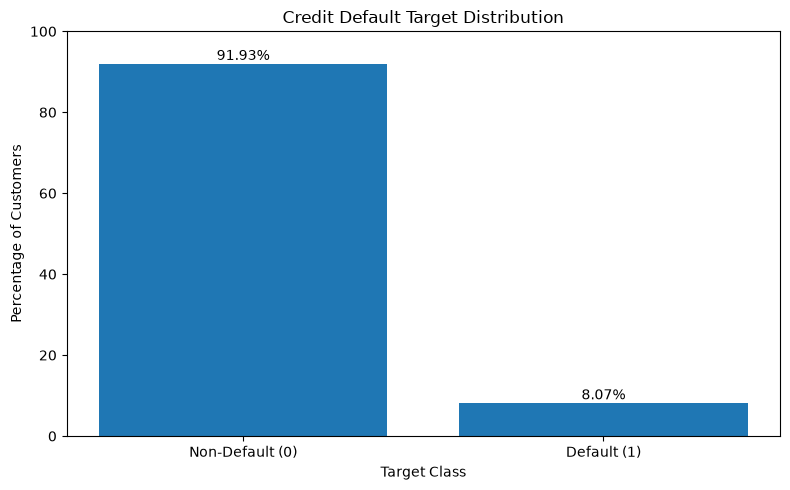

In [24]:
# Calculate target class percentages
target_percentages = (
    df[TARGET_COLUMN]
    .value_counts(normalize=True)
    .sort_index() * 100
)

# Create target distribution plot
plt.figure(figsize=(8, 5))

bars = plt.bar(
    ["Non-Default (0)", "Default (1)"],
    target_percentages.values
)

plt.title("Credit Default Target Distribution")
plt.ylabel("Percentage of Customers")
plt.xlabel("Target Class")

# Add percentage labels
for bar, percentage in zip(bars, target_percentages.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{percentage:.2f}%",
        ha="center"
    )

plt.ylim(0, 100)
plt.tight_layout()
plt.show()

### 2.19 Visualize Missing-Value Distribution

This section visualizes the percentage of missing values across the features with the highest missingness. The visualization helps identify variables that may require removal or specialized treatment during preprocessing.

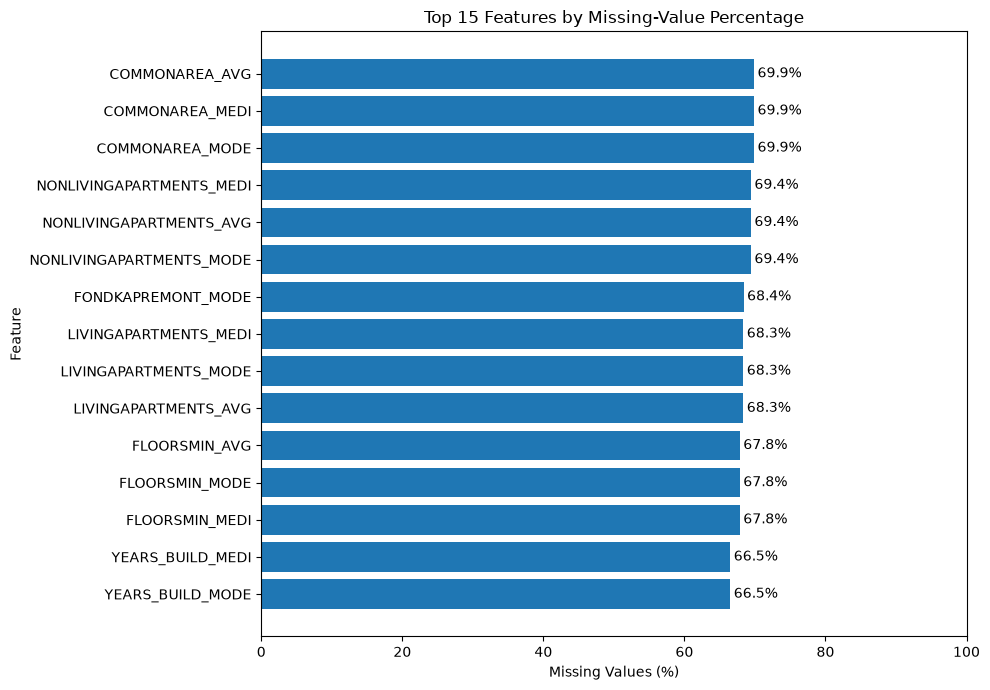

In [25]:
# Select the 15 features with the highest missing-value percentage
top_missing_features = (
    missing_summary
    .sort_values("Missing Percentage", ascending=False)
    .head(15)
    .sort_values("Missing Percentage")
)

# Create missing-value visualization
plt.figure(figsize=(10, 7))

plt.barh(
    top_missing_features.index,
    top_missing_features["Missing Percentage"]
)

plt.title("Top 15 Features by Missing-Value Percentage")
plt.xlabel("Missing Values (%)")
plt.ylabel("Feature")

# Add percentage labels
for index, percentage in enumerate(
    top_missing_features["Missing Percentage"]
):
    plt.text(
        percentage + 0.5,
        index,
        f"{percentage:.1f}%",
        va="center"
    )

plt.xlim(0, 100)
plt.tight_layout()
plt.show()

### 2.20 Visualize Default Rate by Gender

This section examines whether observed default rates differ across the available gender categories. The analysis is descriptive and will be used to understand potential differences in credit-risk outcomes before modelling.

Default rate by gender:


,Default Rate (%)
CODE_GENDER,
M,10.141920
F,6.999328
XNA,0.000000


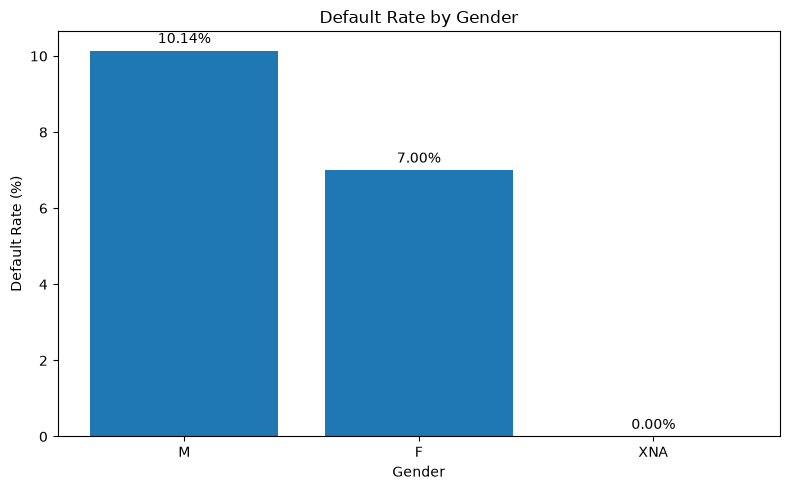

In [26]:
# Calculate default rate by gender
gender_default_rate = (
    df.groupby("CODE_GENDER")[TARGET_COLUMN]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print("Default rate by gender:")
display(gender_default_rate.to_frame("Default Rate (%)"))

# Create visualization
plt.figure(figsize=(8, 5))

bars = plt.bar(
    gender_default_rate.index,
    gender_default_rate.values
)

plt.title("Default Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Default Rate (%)")

# Add percentage labels
for bar, rate in zip(bars, gender_default_rate.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.2,
        f"{rate:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

### 2.21 Visualize Default Rate by Income Type

This section compares observed default rates across borrower income types. The analysis helps identify whether repayment outcomes vary across different borrower profiles and provides context for subsequent feature engineering and risk modelling.

Default rate by income type:


,Default Rate (%)
NAME_INCOME_TYPE,
Maternity leave,40.000000
Unemployed,36.363636
Working,9.588472
Commercial associate,7.484257
State servant,5.754965
Pensioner,5.386366
Businessman,0.000000
Student,0.000000


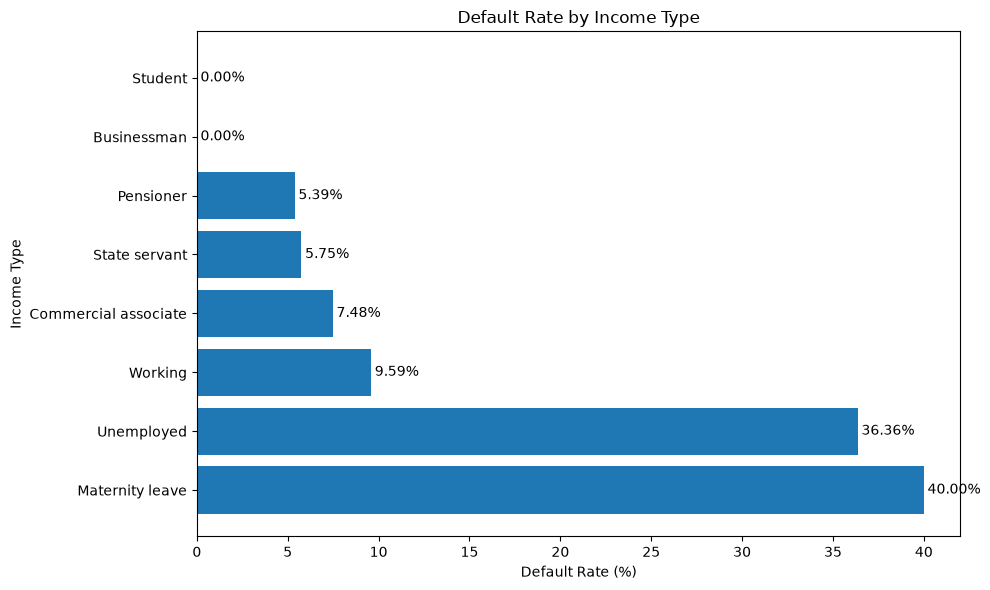

In [27]:
# Calculate default rate by income type
income_type_default_rate = (
    df.groupby("NAME_INCOME_TYPE")[TARGET_COLUMN]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print("Default rate by income type:")
display(
    income_type_default_rate.to_frame("Default Rate (%)")
)

# Create visualization
plt.figure(figsize=(10, 6))

bars = plt.barh(
    income_type_default_rate.index,
    income_type_default_rate.values
)

plt.title("Default Rate by Income Type")
plt.xlabel("Default Rate (%)")
plt.ylabel("Income Type")

# Add percentage labels
for bar, rate in zip(
    bars,
    income_type_default_rate.values
):
    plt.text(
        bar.get_width() + 0.2,
        bar.get_y() + bar.get_height() / 2,
        f"{rate:.2f}%",
        va="center"
    )

plt.tight_layout()
plt.show()

### 2.22 Visualize Default Rate by Education Level

This section compares observed default rates across borrower education levels. The analysis provides additional insight into how borrower characteristics relate to repayment outcomes and supports later risk-feature interpretation.

Default rate by education level:


,Default Rate (%)
NAME_EDUCATION_TYPE,
Lower secondary,10.927673
Secondary / secondary special,8.939929
Incomplete higher,8.484966
Higher education,5.355115
Academic degree,1.829268


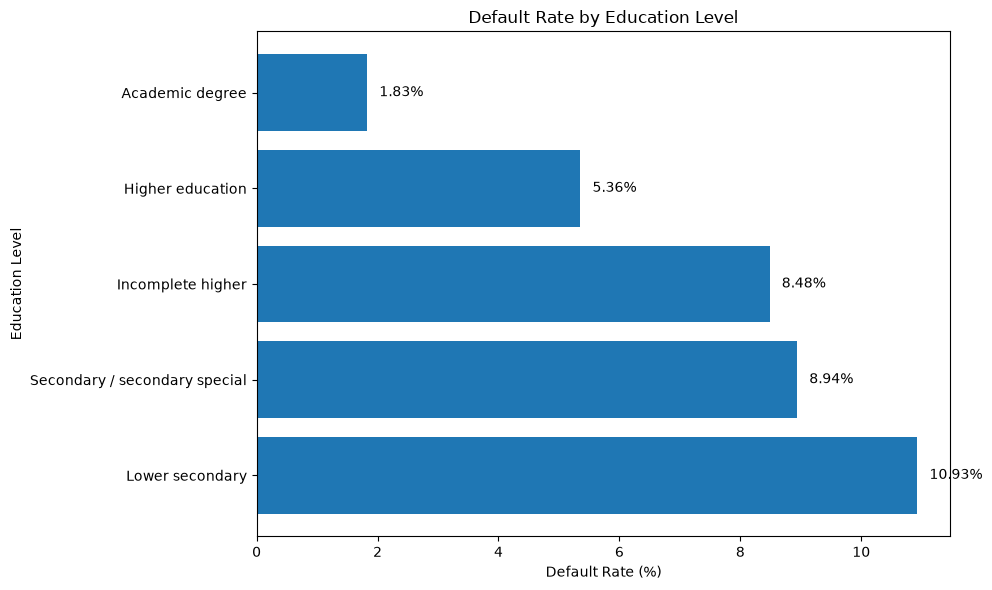

In [29]:
# Calculate default rate by education level
education_default_rate = (
    df.groupby("NAME_EDUCATION_TYPE")[TARGET_COLUMN]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print("Default rate by education level:")
display(
    education_default_rate.to_frame("Default Rate (%)")
)

# Create visualization
plt.figure(figsize=(10, 6))

bars = plt.barh(
    education_default_rate.index,
    education_default_rate.values
)

plt.title("Default Rate by Education Level")
plt.xlabel("Default Rate (%)")
plt.ylabel("Education Level")

# Add percentage labels
for bar, rate in zip(
    bars,
    education_default_rate.values
):
    plt.text(
        bar.get_width() + 0.2,
        bar.get_y() + bar.get_height() / 2,
        f"{rate:.2f}%",
        va="center"
    )

plt.tight_layout()
plt.show()

### 2.23 Visualize Default Rate by Contract Type

This section compares observed default rates across loan contract types. The analysis helps identify differences in repayment outcomes between the available credit products.

Default rate by contract type:


,Default Rate (%)
NAME_CONTRACT_TYPE,
Cash loans,8.345913
Revolving loans,5.478329


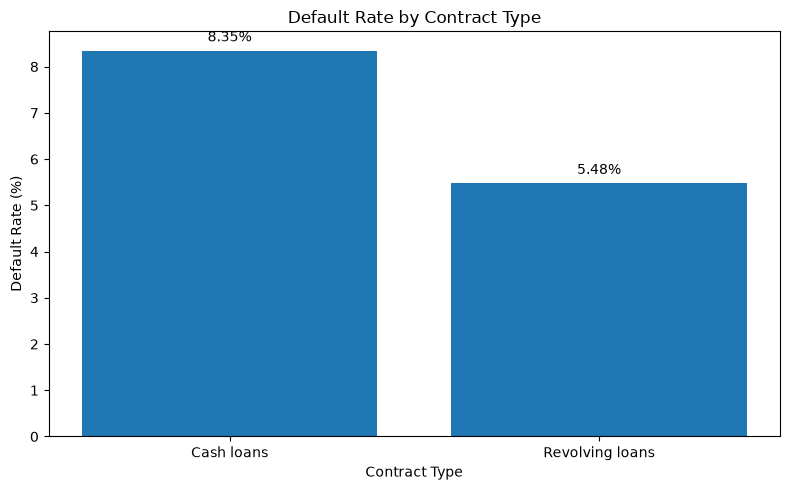

In [30]:
# Calculate default rate by contract type
contract_default_rate = (
    df.groupby("NAME_CONTRACT_TYPE")[TARGET_COLUMN]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print("Default rate by contract type:")
display(
    contract_default_rate.to_frame("Default Rate (%)")
)

# Create visualization
plt.figure(figsize=(8, 5))

bars = plt.bar(
    contract_default_rate.index,
    contract_default_rate.values
)

plt.title("Default Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Default Rate (%)")

# Add percentage labels
for bar, rate in zip(
    bars,
    contract_default_rate.values
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.2,
        f"{rate:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

### 2.24 Visualize Default Rate by Housing Type

This section compares observed default rates across borrower housing types. The analysis provides additional context on how borrower financial and household characteristics relate to repayment outcomes.

Default rate by housing type:


,Default Rate (%)
NAME_HOUSING_TYPE,
Rented apartment,12.313051
With parents,11.698113
Municipal apartment,8.539748
Co-op apartment,7.932264
House / apartment,7.795711
Office apartment,6.572411


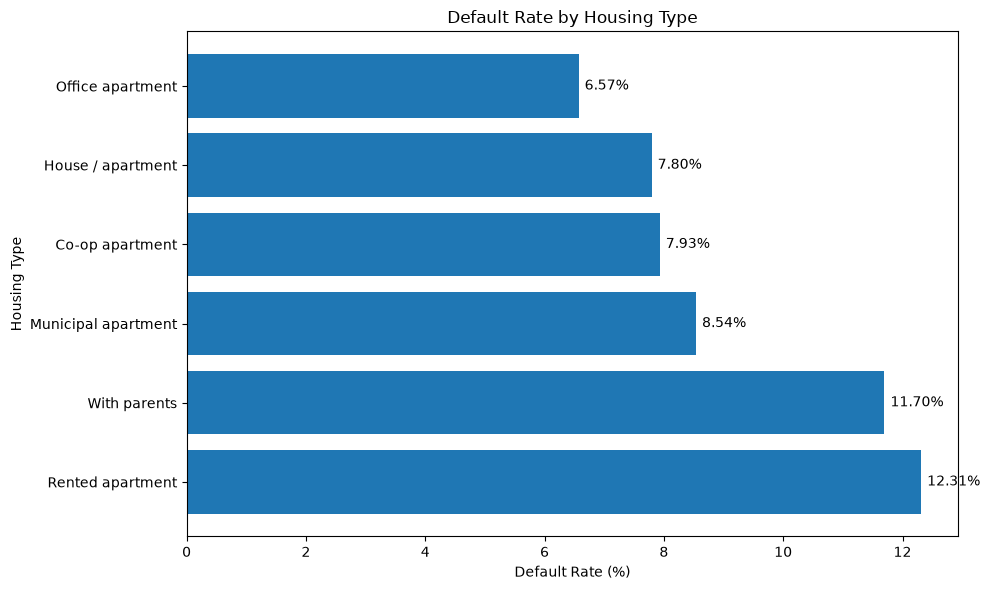

In [31]:
# Calculate default rate by housing type
housing_default_rate = (
    df.groupby("NAME_HOUSING_TYPE")[TARGET_COLUMN]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print("Default rate by housing type:")
display(
    housing_default_rate.to_frame("Default Rate (%)")
)

# Create visualization
plt.figure(figsize=(10, 6))

bars = plt.barh(
    housing_default_rate.index,
    housing_default_rate.values
)

plt.title("Default Rate by Housing Type")
plt.xlabel("Default Rate (%)")
plt.ylabel("Housing Type")

# Add percentage labels
for bar, rate in zip(
    bars,
    housing_default_rate.values
):
    plt.text(
        bar.get_width() + 0.1,
        bar.get_y() + bar.get_height() / 2,
        f"{rate:.2f}%",
        va="center"
    )

plt.tight_layout()
plt.show()

### 2.25 Identify Highly Correlated Numerical Features

Highly correlated numerical variables can introduce redundancy and multicollinearity into the modelling pipeline. This section identifies pairs of numerical features with strong absolute correlation for further consideration during feature selection.

In [3]:
# Calculate the correlation matrix using a representative sample
# to reduce memory usage on the full dataset.

CORRELATION_SAMPLE_SIZE = 50_000

if len(df_clean) > CORRELATION_SAMPLE_SIZE:
    correlation_sample = df_clean.sample(
        n=CORRELATION_SAMPLE_SIZE,
        random_state=RANDOM_STATE
    )
else:
    correlation_sample = df_clean.copy()

# Select numerical features
correlation_sample = correlation_sample[
    numeric_features
].copy()

# Fill missing numerical values using sample medians
correlation_sample = correlation_sample.fillna(
    correlation_sample.median()
)

# Calculate correlation matrix
correlation_matrix = correlation_sample.corr()

# Extract upper triangle to avoid duplicate feature pairs
upper_triangle = correlation_matrix.where(
    np.triu(
        np.ones(correlation_matrix.shape),
        k=1
    ).astype(bool)
)

# Identify highly correlated feature pairs
high_correlation_pairs = (
    upper_triangle.stack()
    .reset_index()
)

high_correlation_pairs.columns = [
    "Feature_1",
    "Feature_2",
    "Correlation"
]

# Keep correlations with absolute value >= 0.80
high_correlation_pairs = (
    high_correlation_pairs[
        high_correlation_pairs["Correlation"].abs() >= 0.80
    ]
    .sort_values(
        "Correlation",
        key=lambda x: x.abs(),
        ascending=False
    )
)

print(
    f"Correlation analysis sample size: "
    f"{len(correlation_sample):,}"
)

print(
    f"Highly correlated feature pairs "
    f"(absolute value >= 0.80): "
    f"{len(high_correlation_pairs):,}"
)

display(
    high_correlation_pairs.head(20)
)

NameError: name 'df_clean' is not defined

### 2.26 Finalize Initial Data-Quality Findings

This section consolidates the key findings from the initial dataset inspection. These findings will directly inform the data-cleaning, preprocessing, feature-engineering, and feature-selection decisions in the next stage of the pipeline.

In [33]:
# Create a final summary of the initial data-quality findings
initial_findings = {
    "Dataset Rows": len(df),
    "Dataset Columns": len(df.columns),
    "Numerical Features": len(numeric_features),
    "Categorical Features": len(categorical_features),
    "Columns With Missing Values": len(missing_summary),
    "Features With >40% Missing Values": len(high_missing_features),
    "Duplicate Records": duplicate_count,
    "Constant Numerical Features": len(constant_features),
    "Near-Constant Numerical Features": len(near_constant_features),
    "Highly Correlated Feature Pairs": len(high_correlation_pairs),
    "Default Rate (%)": round(
        df[TARGET_COLUMN].mean() * 100,
        2
    )
}

initial_findings_df = pd.DataFrame(
    list(initial_findings.items()),
    columns=["Finding", "Value"]
)

display(initial_findings_df)

# Save the final findings
INITIAL_FINDINGS_PATH = REPORT_DIR / "initial_data_quality_findings.csv"

initial_findings_df.to_csv(
    INITIAL_FINDINGS_PATH,
    index=False
)

print("\nInitial data-quality findings saved successfully.")
print(f"File: {INITIAL_FINDINGS_PATH}")

,Finding,Value
0,Dataset Rows,307511.00
1,Dataset Columns,122.00
2,Numerical Features,105.00
3,Categorical Features,16.00
4,Columns With Missing Values,67.00
5,Features With >40% Missing Values,49.00
6,Duplicate Records,0.00
7,Constant Numerical Features,0.00
8,Near-Constant Numerical Features,18.00
9,Highly Correlated Feature Pairs,112.00



Initial data-quality findings saved successfully.
File: C:\Users\dell\Desktop\credit-risk-ml-pipeline\reports\initial_data_quality_findings.csv


## 3. Data Cleaning & Preprocessing

### 3.1 Create a Working Copy of the Raw Dataset

A separate working copy of the raw dataset is created so that the original data remains unchanged. All cleaning and preprocessing operations will be performed on this working dataset.

In [36]:
# Create a working copy for preprocessing
df_clean = df.copy()

print("Working dataset created successfully.")
print(f"Working dataset shape: {df_clean.shape}")

Working dataset created successfully.
Working dataset shape: (307511, 122)


### 3.2 Remove Duplicate Records

Duplicate records identified during the initial data-quality assessment are removed from the working dataset. Removing duplicates prevents repeated observations from receiving disproportionate influence during downstream analysis and modelling.

In [35]:
# Remove duplicate records using memory-efficient row hashing
before_duplicates = len(df_clean)

row_hashes = pd.util.hash_pandas_object(
    df_clean,
    index=False
)

duplicate_mask = row_hashes.duplicated()

df_clean = df_clean.loc[~duplicate_mask].copy()

after_duplicates = len(df_clean)
duplicates_removed = before_duplicates - after_duplicates

print(
    f"Duplicate records removed: "
    f"{duplicates_removed:,}"
)

print(
    f"Working dataset shape: "
    f"{df_clean.shape}"
)

Duplicate records removed: 0
Working dataset shape: (307511, 122)


### 3.3 Remove Features with Excessive Missingness

Features with more than 40% missing values are removed from the modelling dataset because their limited availability can reduce information quality and increase preprocessing complexity. The original raw dataset remains unchanged.

In [37]:
# Identify features with more than 40% missing values
high_missing_columns = (
    df_clean.columns[
        df_clean.isnull().mean() > 0.40
    ]
    .tolist()
)

# Preserve the target variable
high_missing_columns = [
    column
    for column in high_missing_columns
    if column != TARGET_COLUMN
]

# Remove high-missingness features
df_clean = df_clean.drop(columns=high_missing_columns)

print(f"Features removed: {len(high_missing_columns)}")
print(f"Features remaining: {df_clean.shape[1]}")
print(f"Working dataset shape: {df_clean.shape}")


Features removed: 49
Features remaining: 73
Working dataset shape: (307511, 73)


### 3.4 Separate Identifier from Predictive Features

`SK_ID_CURR` is an applicant identifier rather than a meaningful predictive variable. It is retained separately for record tracking but excluded from the predictive feature set to prevent the model from learning arbitrary patterns from the identifier.

In [38]:
# Preserve applicant identifiers separately
ID_COLUMN = "SK_ID_CURR"

applicant_ids = df_clean[ID_COLUMN].copy()

# Remove identifier from the modelling dataset
df_clean = df_clean.drop(columns=[ID_COLUMN])

print(f"Identifier column preserved separately: {ID_COLUMN}")
print(f"Predictive dataset shape: {df_clean.shape}")
print(f"Target column present: {TARGET_COLUMN in df_clean.columns}")

Identifier column preserved separately: SK_ID_CURR
Predictive dataset shape: (307511, 72)
Target column present: True


### 3.5 Reassess Missing Values After Feature Removal

After removing features with excessive missingness, the remaining variables are reassessed to determine the extent of missing data that still requires treatment. Missing-value imputation will be handled within the modelling pipeline to maintain a leakage-safe workflow.

In [39]:
# Recalculate missing values in the cleaned dataset
remaining_missing = pd.DataFrame({
    "Missing Count": df_clean.isnull().sum(),
    "Missing Percentage": (
        df_clean.isnull().mean() * 100
    ).round(2)
})

remaining_missing = (
    remaining_missing[
        remaining_missing["Missing Count"] > 0
    ]
    .sort_values("Missing Percentage", ascending=False)
)

print(
    f"Remaining columns with missing values: "
    f"{len(remaining_missing)}"
)

display(remaining_missing.head(20))

Remaining columns with missing values: 18


,Missing Count,Missing Percentage
OCCUPATION_TYPE,96391,31.35
EXT_SOURCE_3,60965,19.83
AMT_REQ_CREDIT_BUREAU_WEEK,41519,13.50
AMT_REQ_CREDIT_BUREAU_MON,41519,13.50
AMT_REQ_CREDIT_BUREAU_YEAR,41519,13.50
AMT_REQ_CREDIT_BUREAU_QRT,41519,13.50
AMT_REQ_CREDIT_BUREAU_HOUR,41519,13.50
AMT_REQ_CREDIT_BUREAU_DAY,41519,13.50
NAME_TYPE_SUITE,1292,0.42
OBS_30_CNT_SOCIAL_CIRCLE,1021,0.33


### 3.6 Reclassify Numerical and Categorical Features

The feature lists are rebuilt after the removal of high-missingness variables and the applicant identifier. These updated lists will be used in the subsequent preprocessing and machine-learning pipeline.

In [40]:
# Re-identify numerical and categorical features
model_numeric_features = df_clean.select_dtypes(
    include=np.number
).columns.tolist()

model_categorical_features = df_clean.select_dtypes(
    include=["object", "category"]
).columns.tolist()

# Remove target from predictive numerical features
if TARGET_COLUMN in model_numeric_features:
    model_numeric_features.remove(TARGET_COLUMN)

print(
    f"Numerical predictive features: "
    f"{len(model_numeric_features)}"
)

print(
    f"Categorical predictive features: "
    f"{len(model_categorical_features)}"
)

print(
    f"Total predictive features: "
    f"{len(model_numeric_features) + len(model_categorical_features)}"
)

Numerical predictive features: 59
Categorical predictive features: 12
Total predictive features: 71


### 3.7 Validate the Cleaned Dataset

The cleaned dataset is validated to confirm that the target variable remains intact, the identifier has been removed from the predictive dataset, and the expected row count has been preserved before proceeding to train-test splitting and model preprocessing.

In [41]:
# Validate the cleaned dataset
validation_checks = {
    "Expected row count preserved": len(df_clean) == len(df),
    "Target column present": TARGET_COLUMN in df_clean.columns,
    "Identifier removed": ID_COLUMN not in df_clean.columns,
    "No duplicate rows": df_clean.duplicated().sum() == 0,
    "No infinite values": (
        np.isinf(
            df_clean.select_dtypes(include=np.number)
        ).sum().sum() == 0
    )
}

validation_results = pd.DataFrame(
    list(validation_checks.items()),
    columns=["Validation Check", "Passed"]
)

display(validation_results)

if validation_results["Passed"].all():
    print("All data-cleaning validation checks passed.")
else:
    print("One or more validation checks failed. Review the results above.")

,Validation Check,Passed
0,Expected row count preserved,True
1,Target column present,True
2,Identifier removed,True
3,No duplicate rows,True
4,No infinite values,True


All data-cleaning validation checks passed.


### 3.8 Define the Target and Feature Matrix

The cleaned dataset is separated into the target variable and predictive features. The target is kept as a separate vector for model training, while all remaining variables form the feature matrix.

In [42]:
# Separate target from predictive features
X = df_clean.drop(columns=[TARGET_COLUMN])
y = df_clean[TARGET_COLUMN].copy()

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")

print("\nTarget distribution:")
print(y.value_counts())

Feature matrix shape: (307511, 71)
Target vector shape: (307511,)

Target distribution:
TARGET
0    282686
1     24825
Name: count, dtype: int64


### 3.9 Identify Numerical and Categorical Columns for Preprocessing

The feature matrix is divided into numerical and categorical columns for use in a leakage-safe preprocessing pipeline. Numerical variables will receive numerical imputation and scaling, while categorical variables will receive categorical imputation and encoding.

In [43]:
# Identify feature types from X
numeric_features = X.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print(f"Numerical features for preprocessing: {len(numeric_features)}")
print(f"Categorical features for preprocessing: {len(categorical_features)}")

print("\nNumerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features for preprocessing: 59
Categorical features for preprocessing: 12

Numerical features:
['CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL', 'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY', 'HOUR_APPR_PROCESS_START', 'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'OBS_30_CNT_SOCIAL_CIRCLE', 'DEF_30_CNT_SOCIAL_CIRCLE', 'OBS_60_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE', 'DAYS_LAST_PHONE_CHANGE', 'FLAG_DOCUMENT_2', 'FLAG_DOCUMENT_3', 'FLAG_DOCUMENT_4', 'FLAG_DOCUMENT_5', 'FLAG_DOCUMENT_6', 'FLAG_DOCUMENT_7', 'FLAG_DOCUMENT_8', 'FLAG_DOCUMENT_9', 'FLAG_DOCUMENT_10

### 3.10 Check Missing Values in the Modelling Features

Before constructing the preprocessing pipeline, the remaining missing values are reviewed separately for numerical and categorical variables. This confirms which feature groups require imputation.

In [44]:
# Calculate missing values by feature type
numeric_missing = (
    X[numeric_features]
    .isnull()
    .sum()
    .sort_values(ascending=False)
)

categorical_missing = (
    X[categorical_features]
    .isnull()
    .sum()
    .sort_values(ascending=False)
)

print("Numerical features with missing values:")
display(
    numeric_missing[numeric_missing > 0]
    .to_frame("Missing Count")
)

print("\nCategorical features with missing values:")
display(
    categorical_missing[categorical_missing > 0]
    .to_frame("Missing Count")
)

Numerical features with missing values:


,Missing Count
EXT_SOURCE_3,60965
AMT_REQ_CREDIT_BUREAU_YEAR,41519
AMT_REQ_CREDIT_BUREAU_DAY,41519
AMT_REQ_CREDIT_BUREAU_HOUR,41519
AMT_REQ_CREDIT_BUREAU_MON,41519
AMT_REQ_CREDIT_BUREAU_WEEK,41519
AMT_REQ_CREDIT_BUREAU_QRT,41519
OBS_30_CNT_SOCIAL_CIRCLE,1021
DEF_30_CNT_SOCIAL_CIRCLE,1021
OBS_60_CNT_SOCIAL_CIRCLE,1021



Categorical features with missing values:


,Missing Count
OCCUPATION_TYPE,96391
NAME_TYPE_SUITE,1292


### 3.11 Split the Dataset into Training and Test Sets

The modelling dataset is divided into training and test sets before fitting any preprocessing transformations. This prevents information from the test set from influencing imputation, encoding, scaling, or subsequent model development.

In [45]:
# Split the data into training and test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print(f"Training feature shape: {X_train.shape}")
print(f"Test feature shape: {X_test.shape}")

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).mul(100).round(2))

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True).mul(100).round(2))

Training feature shape: (246008, 71)
Test feature shape: (61503, 71)

Training target distribution:
TARGET
0    91.93
1     8.07
Name: proportion, dtype: float64

Test target distribution:
TARGET
0    91.93
1     8.07
Name: proportion, dtype: float64


### 3.12 Build the Numerical Preprocessing Pipeline

A preprocessing pipeline is created for numerical variables using median imputation followed by standardization. The preprocessing steps will be fitted only on the training data to prevent data leakage into the test set.

In [48]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Numerical preprocessing pipeline
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

print("Numerical preprocessing pipeline created successfully.")
print("Steps: Median Imputation → Standard Scaling")

Numerical preprocessing pipeline created successfully.
Steps: Median Imputation → Standard Scaling


### 3.13 Build the Categorical Preprocessing Pipeline

Categorical variables are prepared using most-frequent-value imputation followed by one-hot encoding. Unknown categories encountered in future data are ignored to ensure the pipeline remains robust during model evaluation and deployment.

In [49]:
from sklearn.preprocessing import OneHotEncoder

# Categorical preprocessing pipeline
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

print("Categorical preprocessing pipeline created successfully.")
print("Steps: Most-Frequent Imputation → One-Hot Encoding")

Categorical preprocessing pipeline created successfully.
Steps: Most-Frequent Imputation → One-Hot Encoding


### 3.14 Combine Numerical and Categorical Preprocessing

The numerical and categorical preprocessing pipelines are combined into a single column transformer. This ensures that each feature type receives the appropriate transformation while maintaining a consistent preprocessing workflow.

In [50]:
from sklearn.compose import ColumnTransformer

# Combine numerical and categorical preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Combined preprocessing pipeline created successfully.")
print("Numerical features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Combined preprocessing pipeline created successfully.
Numerical features: 59
Categorical features: 12


### 3.15 Fit the Preprocessing Pipeline on Training Data

The combined preprocessing pipeline is fitted exclusively on the training dataset. This ensures that information from the test set is not used during imputation or encoding, preventing data leakage.

In [51]:
# Fit preprocessing pipeline using training data only
preprocessor.fit(X_train)

print("Preprocessing pipeline fitted successfully on training data.")

Preprocessing pipeline fitted successfully on training data.


### 3.16 Transform Training and Test Data

The fitted preprocessing pipeline is applied to both training and test datasets. The test data is transformed using parameters learned exclusively from the training data.

In [52]:
# Transform training and test datasets
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"Processed training data shape: {X_train_processed.shape}")
print(f"Processed test data shape: {X_test_processed.shape}")

Processed training data shape: (246008, 183)
Processed test data shape: (61503, 183)


### 3.17 Verify the Processed Feature Matrix

The processed feature matrices are validated to confirm that preprocessing has been successfully applied and that the resulting matrices contain no missing values.

In [54]:
# Verify processed matrices
print("Training matrix type:", type(X_train_processed))
print("Test matrix type:", type(X_test_processed))

print("\nTraining matrix shape:", X_train_processed.shape)
print("Test matrix shape:", X_test_processed.shape)

# Check for missing values
print(
    "\nMissing values in training matrix:",
    np.isnan(X_train_processed).sum()
)

print(
    "Missing values in test matrix:",
    np.isnan(X_test_processed).sum()
)

Training matrix type: <class 'numpy.ndarray'>
Test matrix type: <class 'numpy.ndarray'>

Training matrix shape: (246008, 183)
Test matrix shape: (61503, 183)

Missing values in training matrix: 0
Missing values in test matrix: 0


### 3.18 Save the Preprocessing Pipeline

The fitted preprocessing pipeline is saved to the project directory so that the exact same transformations can be reused during model evaluation and future prediction.

In [56]:
import joblib

# Define project and model directories
BASE_DIR = Path(r"C:\Users\dell\Desktop\credit-risk-ml-pipeline")
MODEL_DIR = BASE_DIR / "models"

MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Save fitted preprocessing pipeline
PREPROCESSOR_PATH = MODEL_DIR / "preprocessor.pkl"

joblib.dump(preprocessor, PREPROCESSOR_PATH)

print("Preprocessing pipeline saved successfully.")
print(f"File: {PREPROCESSOR_PATH}")

Preprocessing pipeline saved successfully.
File: C:\Users\dell\Desktop\credit-risk-ml-pipeline\models\preprocessor.pkl


### 3.19 Save Processed Training and Test Data

The processed training and test feature matrices are saved for reproducibility and future model development. The target vectors are saved separately to preserve the distinction between predictive features and the modelling outcome.

In [57]:
# Define processed data directory
PROCESSED_DIR = BASE_DIR / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# Save processed feature matrices
np.save(
    PROCESSED_DIR / "X_train_processed.npy",
    X_train_processed
)

np.save(
    PROCESSED_DIR / "X_test_processed.npy",
    X_test_processed
)

# Save target vectors
np.save(
    PROCESSED_DIR / "y_train.npy",
    y_train.to_numpy()
)

np.save(
    PROCESSED_DIR / "y_test.npy",
    y_test.to_numpy()
)

print("Processed datasets saved successfully.")
print(f"Directory: {PROCESSED_DIR}")

Processed datasets saved successfully.
Directory: C:\Users\dell\Desktop\credit-risk-ml-pipeline\data\processed


### 3.20 Final Preprocessing Validation

The complete preprocessing stage is validated by checking dataset dimensions, target alignment, and the absence of missing values in the transformed matrices. These checks confirm that the data is ready for machine-learning model development.

In [58]:
# Final preprocessing validation
preprocessing_validation = {
    "Training rows preserved": X_train_processed.shape[0] == len(y_train),
    "Test rows preserved": X_test_processed.shape[0] == len(y_test),
    "Training features match test features": (
        X_train_processed.shape[1] == X_test_processed.shape[1]
    ),
    "No missing values in training data": (
        np.isnan(X_train_processed).sum() == 0
    ),
    "No missing values in test data": (
        np.isnan(X_test_processed).sum() == 0
    ),
    "Training target aligned": X_train_processed.shape[0] == len(y_train),
    "Test target aligned": X_test_processed.shape[0] == len(y_test)
}

preprocessing_validation_df = pd.DataFrame(
    list(preprocessing_validation.items()),
    columns=["Validation Check", "Passed"]
)

display(preprocessing_validation_df)

if preprocessing_validation_df["Passed"].all():
    print("All preprocessing validation checks passed.")
else:
    print("One or more preprocessing checks failed.")

,Validation Check,Passed
0,Training rows preserved,True
1,Test rows preserved,True
2,Training features match test features,True
3,No missing values in training data,True
4,No missing values in test data,True
5,Training target aligned,True
6,Test target aligned,True


All preprocessing validation checks passed.


## 4. PySpark Processing

### 4.1 Create Spark DataFrame from the Cleaned Dataset

The cleaned dataset is converted from a Pandas DataFrame into a PySpark DataFrame. This introduces distributed data-processing capability into the credit-risk pipeline while preserving the cleaned feature structure.

In [59]:
# Convert cleaned Pandas DataFrame to PySpark DataFrame
spark_df = spark.createDataFrame(df_clean)

print("PySpark DataFrame created successfully.")
print(f"Rows: {spark_df.count():,}")
print(f"Columns: {len(spark_df.columns)}")

PySpark DataFrame created successfully.
Rows: 307,511
Columns: 72


### 4.2 Inspect PySpark Schema

The PySpark schema is inspected to verify column names and data types after conversion from Pandas. This confirms that the Spark DataFrame is correctly structured for distributed processing.

In [60]:
# Inspect PySpark schema
spark_df.printSchema()

root
 |-- TARGET: long (nullable = true)
 |-- NAME_CONTRACT_TYPE: string (nullable = true)
 |-- CODE_GENDER: string (nullable = true)
 |-- FLAG_OWN_CAR: string (nullable = true)
 |-- FLAG_OWN_REALTY: string (nullable = true)
 |-- CNT_CHILDREN: long (nullable = true)
 |-- AMT_INCOME_TOTAL: double (nullable = true)
 |-- AMT_CREDIT: double (nullable = true)
 |-- AMT_ANNUITY: double (nullable = true)
 |-- AMT_GOODS_PRICE: double (nullable = true)
 |-- NAME_TYPE_SUITE: string (nullable = true)
 |-- NAME_INCOME_TYPE: string (nullable = true)
 |-- NAME_EDUCATION_TYPE: string (nullable = true)
 |-- NAME_FAMILY_STATUS: string (nullable = true)
 |-- NAME_HOUSING_TYPE: string (nullable = true)
 |-- REGION_POPULATION_RELATIVE: double (nullable = true)
 |-- DAYS_BIRTH: long (nullable = true)
 |-- DAYS_EMPLOYED: long (nullable = true)
 |-- DAYS_REGISTRATION: double (nullable = true)
 |-- DAYS_ID_PUBLISH: long (nullable = true)
 |-- FLAG_MOBIL: long (nullable = true)
 |-- FLAG_EMP_PHONE: long (nullab

### 4.3 Calculate Basic PySpark Data-Quality Metrics

Basic data-quality metrics are calculated directly using PySpark, including row count, column count, and duplicate-record count. This demonstrates data validation within the Spark processing layer rather than relying only on Pandas.

In [61]:
# Calculate basic PySpark data-quality metrics
spark_row_count = spark_df.count()
spark_column_count = len(spark_df.columns)
spark_duplicate_count = spark_df.count() - spark_df.dropDuplicates().count()

print(f"Spark row count: {spark_row_count:,}")
print(f"Spark column count: {spark_column_count}")
print(f"Spark duplicate records: {spark_duplicate_count:,}")

Spark row count: 307,511
Spark column count: 72
Spark duplicate records: 0


### 4.4 Inspect Missing Values Using PySpark

Missing-value counts are calculated directly within the PySpark DataFrame. This identifies which columns still contain missing observations after the earlier data-cleaning stage.

In [62]:
# Calculate missing values for each column using PySpark
missing_counts = spark_df.select([
    F.sum(F.col(column).isNull().cast("int")).alias(column)
    for column in spark_df.columns
])

missing_summary = missing_counts.toPandas().T.reset_index()
missing_summary.columns = ["Column", "Missing Count"]

missing_summary = missing_summary[
    missing_summary["Missing Count"] > 0
].sort_values(
    "Missing Count",
    ascending=False
)

print(f"Columns with missing values: {len(missing_summary)}")
display(missing_summary)

Columns with missing values: 18


,Column,Missing Count
26,OCCUPATION_TYPE,96391
40,EXT_SOURCE_3,60965
68,AMT_REQ_CREDIT_BUREAU_WEEK,41519
69,AMT_REQ_CREDIT_BUREAU_MON,41519
71,AMT_REQ_CREDIT_BUREAU_YEAR,41519
70,AMT_REQ_CREDIT_BUREAU_QRT,41519
66,AMT_REQ_CREDIT_BUREAU_HOUR,41519
67,AMT_REQ_CREDIT_BUREAU_DAY,41519
10,NAME_TYPE_SUITE,1292
41,OBS_30_CNT_SOCIAL_CIRCLE,1021


### 4.5 Create a PySpark Summary of Numerical Features

PySpark is used to generate summary statistics for numerical variables, including count, mean, standard deviation, minimum, and maximum values. This provides a scalable overview of the numerical feature distributions.

In [63]:
# Identify numerical columns in the Spark DataFrame
spark_numeric_columns = [
    field.name
    for field in spark_df.schema.fields
    if field.dataType.simpleString() in ["int", "bigint", "double", "float"]
]

# Generate summary statistics
spark_numeric_summary = spark_df.select(
    spark_numeric_columns
).summary(
    "count",
    "mean",
    "stddev",
    "min",
    "max"
)

display(spark_numeric_summary)

print(
    f"Numerical columns summarized: "
    f"{len(spark_numeric_columns)}"
)

DataFrame[summary: string, TARGET: string, CNT_CHILDREN: string, AMT_INCOME_TOTAL: string, AMT_CREDIT: string, AMT_ANNUITY: string, AMT_GOODS_PRICE: string, REGION_POPULATION_RELATIVE: string, DAYS_BIRTH: string, DAYS_EMPLOYED: string, DAYS_REGISTRATION: string, DAYS_ID_PUBLISH: string, FLAG_MOBIL: string, FLAG_EMP_PHONE: string, FLAG_WORK_PHONE: string, FLAG_CONT_MOBILE: string, FLAG_PHONE: string, FLAG_EMAIL: string, CNT_FAM_MEMBERS: string, REGION_RATING_CLIENT: string, REGION_RATING_CLIENT_W_CITY: string, HOUR_APPR_PROCESS_START: string, REG_REGION_NOT_LIVE_REGION: string, REG_REGION_NOT_WORK_REGION: string, LIVE_REGION_NOT_WORK_REGION: string, REG_CITY_NOT_LIVE_CITY: string, REG_CITY_NOT_WORK_CITY: string, LIVE_CITY_NOT_WORK_CITY: string, EXT_SOURCE_2: string, EXT_SOURCE_3: string, OBS_30_CNT_SOCIAL_CIRCLE: string, DEF_30_CNT_SOCIAL_CIRCLE: string, OBS_60_CNT_SOCIAL_CIRCLE: string, DEF_60_CNT_SOCIAL_CIRCLE: string, DAYS_LAST_PHONE_CHANGE: string, FLAG_DOCUMENT_2: string, FLAG_DOCU

Numerical columns summarized: 60


### 4.6 Create a PySpark Target Distribution

The target variable is aggregated using PySpark to verify the distribution of default and non-default observations within the Spark processing layer.

In [64]:
# Calculate target distribution using PySpark
spark_target_distribution = (
    spark_df
    .groupBy(TARGET_COLUMN)
    .count()
    .withColumn(
        "Percentage",
        F.round(
            F.col("count") / spark_df.count() * 100,
            2
        )
    )
    .orderBy(TARGET_COLUMN)
)

display(spark_target_distribution)

DataFrame[TARGET: bigint, count: bigint, Percentage: double]

## 5. Exploratory Data Analysis

### 5.1 Analyze Target Distribution

The target variable is analyzed to understand the distribution between default and non-default observations. This establishes the degree of class imbalance that will be considered during model development and evaluation.

,Target,Count,Percentage
0,0,282686,91.93
1,1,24825,8.07


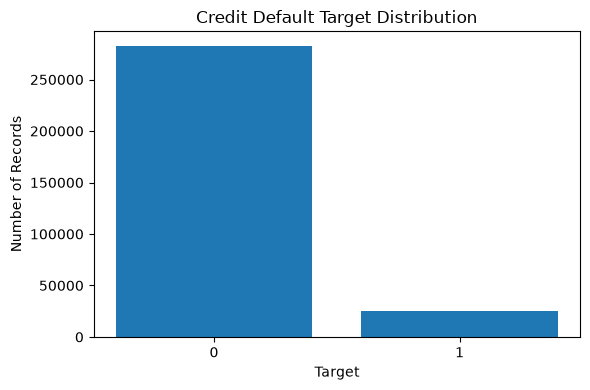

In [65]:
# Analyze target distribution
target_counts = y.value_counts().sort_index()

target_distribution = pd.DataFrame({
    "Target": target_counts.index,
    "Count": target_counts.values,
    "Percentage": (
        target_counts.values / len(y) * 100
    ).round(2)
})

display(target_distribution)

# Visualize target distribution
plt.figure(figsize=(6, 4))

plt.bar(
    target_distribution["Target"].astype(str),
    target_distribution["Count"]
)

plt.title("Credit Default Target Distribution")
plt.xlabel("Target")
plt.ylabel("Number of Records")

plt.tight_layout()
plt.show()

### 5.2 Analyze Numerical Feature Distributions

Key numerical credit and borrower variables are examined to understand their distributions and identify potential skewness or unusual values. This analysis helps inform subsequent feature engineering and modelling decisions.

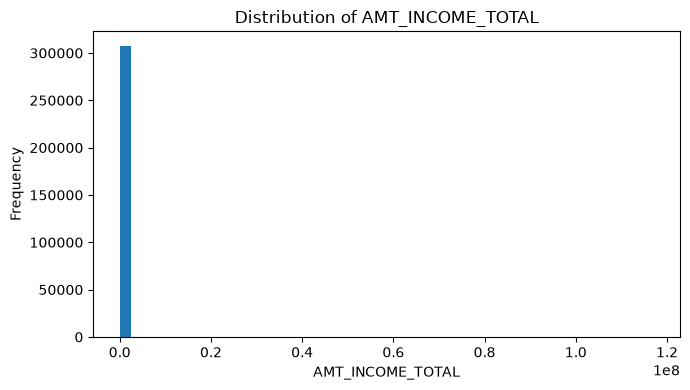

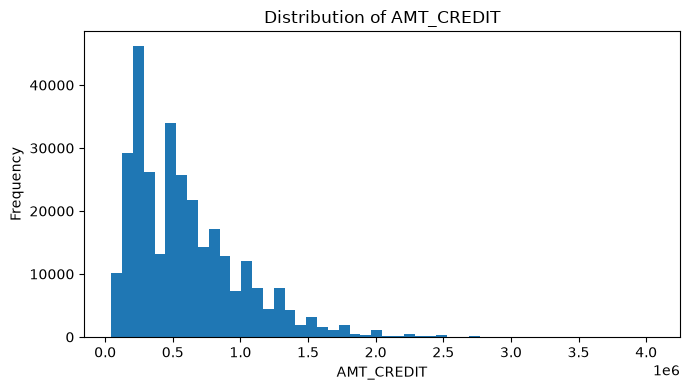

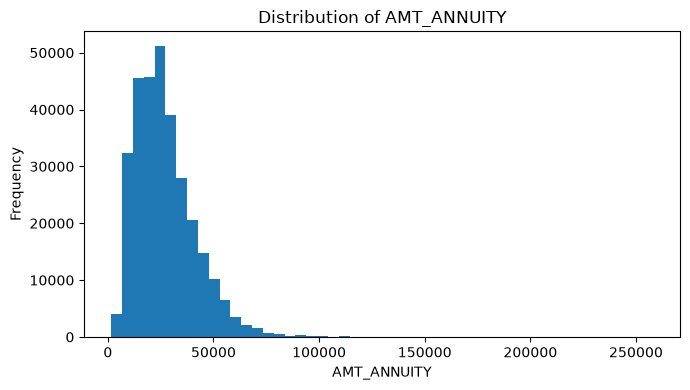

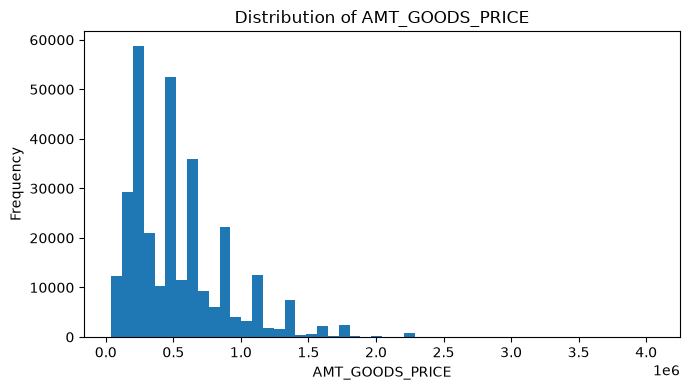

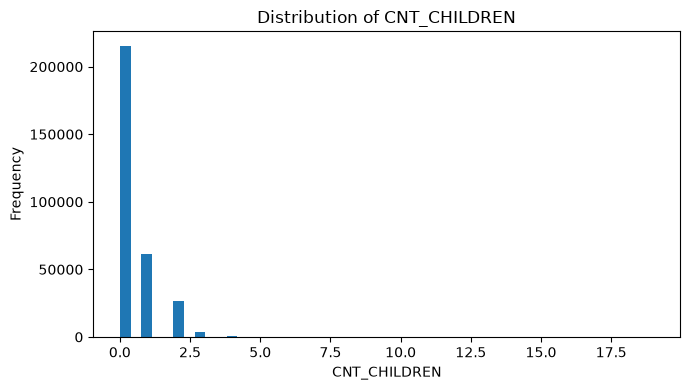

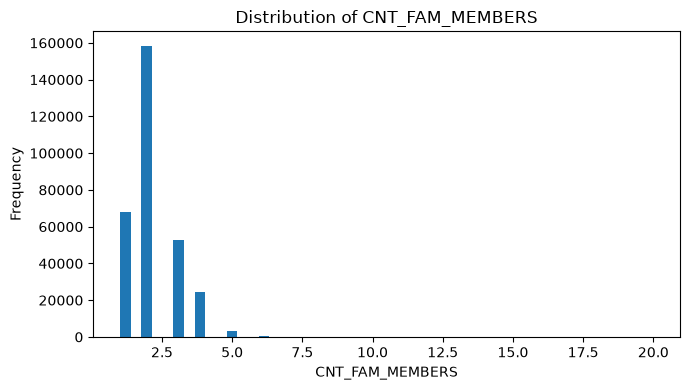

In [66]:
# Select key numerical variables for distribution analysis
eda_numeric_features = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
    "CNT_CHILDREN",
    "CNT_FAM_MEMBERS"
]

# Plot distributions
for column in eda_numeric_features:
    plt.figure(figsize=(7, 4))

    plt.hist(
        df[column].dropna(),
        bins=50
    )

    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

### 5.3 Analyze Missingness Patterns

The remaining missing values are analyzed to identify the features with the highest levels of missingness. Understanding these patterns helps determine appropriate preprocessing and feature-engineering strategies.

,Feature,Missing Percentage
0,OCCUPATION_TYPE,31.345545
1,EXT_SOURCE_3,19.825307
2,AMT_REQ_CREDIT_BUREAU_QRT,13.501631
3,AMT_REQ_CREDIT_BUREAU_YEAR,13.501631
4,AMT_REQ_CREDIT_BUREAU_MON,13.501631
5,AMT_REQ_CREDIT_BUREAU_WEEK,13.501631
6,AMT_REQ_CREDIT_BUREAU_DAY,13.501631
7,AMT_REQ_CREDIT_BUREAU_HOUR,13.501631
8,NAME_TYPE_SUITE,0.420148
9,OBS_30_CNT_SOCIAL_CIRCLE,0.332021


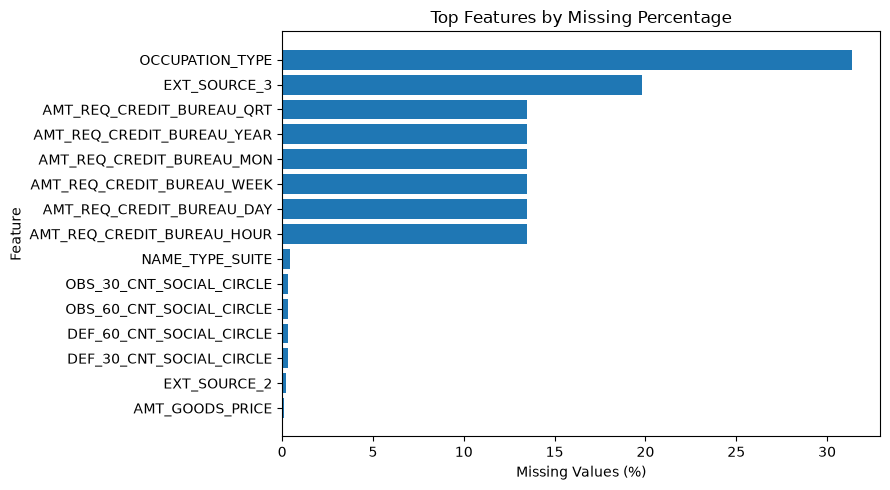

In [67]:
# Analyze remaining missingness
eda_missing = (
    df_clean.isnull()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

eda_missing = (
    eda_missing[eda_missing > 0]
    .head(15)
    .reset_index()
)

eda_missing.columns = [
    "Feature",
    "Missing Percentage"
]

display(eda_missing)

# Visualize missingness
plt.figure(figsize=(9, 5))

plt.barh(
    eda_missing["Feature"],
    eda_missing["Missing Percentage"]
)

plt.title("Top Features by Missing Percentage")
plt.xlabel("Missing Values (%)")
plt.ylabel("Feature")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### 5.4 Analyze Categorical Feature Distributions

Key categorical borrower characteristics are examined to understand their distribution across the dataset. This helps identify dominant categories and potential sparsity that may influence feature engineering and model performance.

In [68]:
# Select key categorical variables for analysis
eda_categorical_features = [
    "NAME_CONTRACT_TYPE",
    "CODE_GENDER",
    "NAME_INCOME_TYPE",
    "NAME_EDUCATION_TYPE",
    "NAME_FAMILY_STATUS"
]

# Display category distributions
for column in eda_categorical_features:
    print(f"\n{column} distribution:")
    display(
        df_clean[column]
        .value_counts(dropna=False)
        .to_frame("Count")
    )


NAME_CONTRACT_TYPE distribution:


,Count
NAME_CONTRACT_TYPE,
Cash loans,278232
Revolving loans,29279



CODE_GENDER distribution:


,Count
CODE_GENDER,
F,202448
M,105059
XNA,4



NAME_INCOME_TYPE distribution:


,Count
NAME_INCOME_TYPE,
Working,158774
Commercial associate,71617
Pensioner,55362
State servant,21703
Unemployed,22
Student,18
Businessman,10
Maternity leave,5



NAME_EDUCATION_TYPE distribution:


,Count
NAME_EDUCATION_TYPE,
Secondary / secondary special,218391
Higher education,74863
Incomplete higher,10277
Lower secondary,3816
Academic degree,164



NAME_FAMILY_STATUS distribution:


,Count
NAME_FAMILY_STATUS,
Married,196432
Single / not married,45444
Civil marriage,29775
Separated,19770
Widow,16088
Unknown,2


### 5.5 Analyze Default Rates by Key Borrower Characteristics

Default rates are compared across important categorical borrower characteristics. This analysis helps identify groups with materially different observed default rates and provides business context for subsequent feature engineering.

In [69]:
# Calculate default rates across key categorical features
for column in eda_categorical_features:
    
    default_rate = (
        df_clean
        .groupby(column, dropna=False)[TARGET_COLUMN]
        .agg(["count", "mean"])
        .reset_index()
    )
    
    default_rate["Default Rate (%)"] = (
        default_rate["mean"] * 100
    ).round(2)
    
    default_rate = default_rate.drop(
        columns=["mean"]
    ).sort_values(
        "Default Rate (%)",
        ascending=False
    )
    
    print(f"\nDefault rate by {column}:")
    display(default_rate)


Default rate by NAME_CONTRACT_TYPE:


,NAME_CONTRACT_TYPE,count,Default Rate (%)
0,Cash loans,278232,8.35
1,Revolving loans,29279,5.48



Default rate by CODE_GENDER:


,CODE_GENDER,count,Default Rate (%)
1,M,105059,10.14
0,F,202448,7.00
2,XNA,4,0.00



Default rate by NAME_INCOME_TYPE:


,NAME_INCOME_TYPE,count,Default Rate (%)
2,Maternity leave,5,40.00
6,Unemployed,22,36.36
7,Working,158774,9.59
1,Commercial associate,71617,7.48
4,State servant,21703,5.75
3,Pensioner,55362,5.39
0,Businessman,10,0.00
5,Student,18,0.00



Default rate by NAME_EDUCATION_TYPE:


,NAME_EDUCATION_TYPE,count,Default Rate (%)
3,Lower secondary,3816,10.93
4,Secondary / secondary special,218391,8.94
2,Incomplete higher,10277,8.48
1,Higher education,74863,5.36
0,Academic degree,164,1.83



Default rate by NAME_FAMILY_STATUS:


,NAME_FAMILY_STATUS,count,Default Rate (%)
0,Civil marriage,29775,9.94
3,Single / not married,45444,9.81
2,Separated,19770,8.19
1,Married,196432,7.56
5,Widow,16088,5.82
4,Unknown,2,0.00


### 5.6 Analyze Feature Correlations

Correlations between selected numerical variables are examined to identify relationships that may be relevant for feature engineering and model development. The analysis focuses on meaningful financial and credit-related variables rather than indiscriminately correlating every feature.

,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,CNT_CHILDREN,CNT_FAM_MEMBERS,REGION_POPULATION_RELATIVE,EXT_SOURCE_2,EXT_SOURCE_3
AMT_INCOME_TOTAL,1.00,0.16,0.19,0.16,0.01,0.02,0.07,0.06,-0.03
AMT_CREDIT,0.16,1.00,0.77,0.99,0.00,0.06,0.10,0.13,0.04
AMT_ANNUITY,0.19,0.77,1.00,0.78,0.02,0.08,0.12,0.13,0.03
AMT_GOODS_PRICE,0.16,0.99,0.78,1.00,-0.00,0.06,0.10,0.14,0.05
CNT_CHILDREN,0.01,0.00,0.02,-0.00,1.00,0.88,-0.03,-0.02,-0.04
CNT_FAM_MEMBERS,0.02,0.06,0.08,0.06,0.88,1.00,-0.02,-0.00,-0.03
REGION_POPULATION_RELATIVE,0.07,0.10,0.12,0.10,-0.03,-0.02,1.00,0.20,-0.01
EXT_SOURCE_2,0.06,0.13,0.13,0.14,-0.02,-0.00,0.20,1.00,0.11
EXT_SOURCE_3,-0.03,0.04,0.03,0.05,-0.04,-0.03,-0.01,0.11,1.00


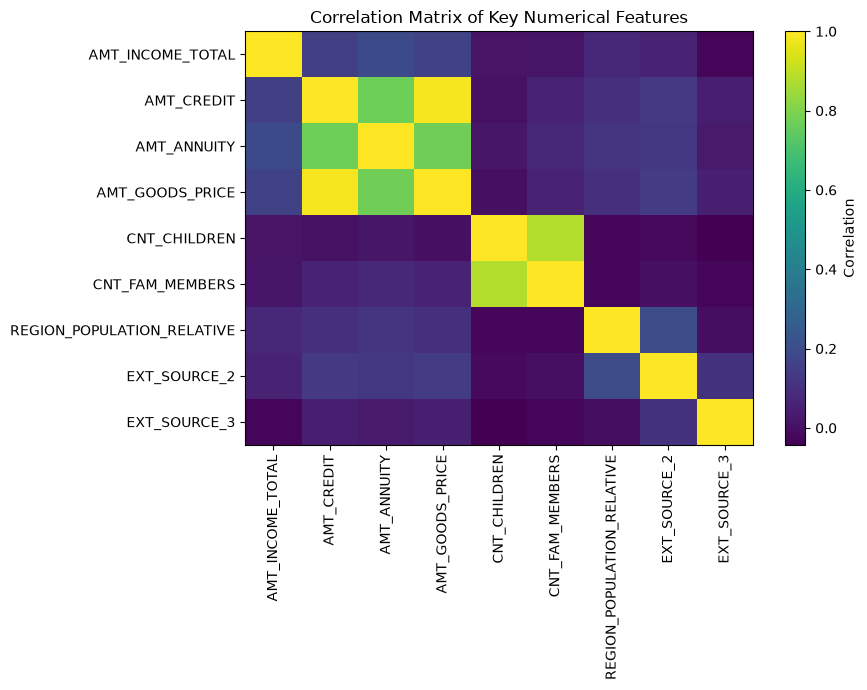

In [70]:
# Select key numerical features for correlation analysis
correlation_features = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
    "CNT_CHILDREN",
    "CNT_FAM_MEMBERS",
    "REGION_POPULATION_RELATIVE",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3"
]

# Calculate correlation matrix
correlation_matrix = (
    df_clean[correlation_features]
    .corr()
)

display(correlation_matrix.round(2))

# Visualize correlation matrix
plt.figure(figsize=(9, 7))

plt.imshow(
    correlation_matrix,
    aspect="auto"
)

plt.xticks(
    range(len(correlation_features)),
    correlation_features,
    rotation=90
)

plt.yticks(
    range(len(correlation_features)),
    correlation_features
)

plt.colorbar(label="Correlation")
plt.title("Correlation Matrix of Key Numerical Features")

plt.tight_layout()
plt.show()

## 6. Data Leakage Prevention

### 6.1 Document Leakage Prevention Strategy

Data leakage is explicitly addressed to ensure that information unavailable at prediction time does not influence model development. The workflow separates training and test data before preprocessing, fits transformations only on training data, excludes target-derived information, and preserves the test set as a final holdout.

In [71]:
# Verify the main leakage-prevention conditions
leakage_checks = {
    "Train/test split performed": (
        len(X_train) + len(X_test) == len(X)
    ),
    "Training and test sets are separate": (
        set(X_train.index).isdisjoint(set(X_test.index))
    ),
    "Preprocessor fitted on training data": (
        hasattr(preprocessor, "transformers_")
    ),
    "Target excluded from features": (
        TARGET_COLUMN not in X.columns
    ),
    "Identifier excluded from features": (
        ID_COLUMN not in X.columns
    )
}

leakage_validation = pd.DataFrame(
    list(leakage_checks.items()),
    columns=["Leakage Check", "Passed"]
)

display(leakage_validation)

if leakage_validation["Passed"].all():
    print("All primary leakage-prevention checks passed.")
else:
    print("One or more leakage checks require review.")

,Leakage Check,Passed
0,Train/test split performed,True
1,Training and test sets are separate,True
2,Preprocessor fitted on training data,True
3,Target excluded from features,True
4,Identifier excluded from features,True


All primary leakage-prevention checks passed.


### 6.2 Verify Target Leakage

The feature set is checked for columns that directly duplicate or explicitly reference the target variable. Such variables would provide the model with information about the outcome it is supposed to predict and must therefore be excluded.

In [72]:
# Check for direct target leakage in feature names
target_related_features = [
    column
    for column in X.columns
    if TARGET_COLUMN.lower() in column.lower()
]

print("Target-related features identified:")
print(target_related_features)

if len(target_related_features) == 0:
    print("\nNo direct target-related feature names detected.")
else:
    print(
        "\nReview the features above for potential target leakage."
    )

Target-related features identified:
[]

No direct target-related feature names detected.


### 6.3 Verify Identifier Leakage

Applicant identifiers are checked to ensure that unique record identifiers are not included in the predictive feature matrix. Identifiers can introduce arbitrary patterns that do not represent meaningful borrower risk.

In [73]:
# Verify that the applicant identifier is excluded
identifier_present = ID_COLUMN in X.columns

print(f"Identifier column: {ID_COLUMN}")
print(f"Present in feature matrix: {identifier_present}")

if not identifier_present:
    print("Identifier leakage check passed.")
else:
    print("Identifier is still present and must be removed.")

Identifier column: SK_ID_CURR
Present in feature matrix: False
Identifier leakage check passed.


### 6.4 Verify Preprocessing Was Fit Only on Training Data

The preprocessing workflow is verified to ensure that imputation, scaling, and categorical encoding were learned from the training dataset before being applied to the test dataset. This prevents information from the test set from influencing model preparation.

In [74]:
# Verify preprocessing workflow
print("Preprocessor fitted:", hasattr(preprocessor, "transformers_"))
print("Training data shape before preprocessing:", X_train.shape)
print("Test data shape before preprocessing:", X_test.shape)
print("Training data shape after preprocessing:", X_train_processed.shape)
print("Test data shape after preprocessing:", X_test_processed.shape)

if hasattr(preprocessor, "transformers_"):
    print("\nPreprocessing leakage check passed.")
else:
    print("\nPreprocessing pipeline has not been fitted.")

Preprocessor fitted: True
Training data shape before preprocessing: (246008, 71)
Test data shape before preprocessing: (61503, 71)
Training data shape after preprocessing: (246008, 183)
Test data shape after preprocessing: (61503, 183)

Preprocessing leakage check passed.


### 6.5 Verify Test Data Remains Unused for Model Fitting

The modelling workflow is structured so that the test dataset remains a final holdout. It is used only after model development and preprocessing decisions are finalized, providing an unbiased estimate of out-of-sample performance.

In [75]:
# Verify separation of training and test datasets
train_indices = set(X_train.index)
test_indices = set(X_test.index)

print(f"Training observations: {len(train_indices):,}")
print(f"Test observations: {len(test_indices):,}")
print(
    f"Overlapping observations: "
    f"{len(train_indices.intersection(test_indices))}"
)

if train_indices.isdisjoint(test_indices):
    print("\nTraining/test separation check passed.")
else:
    print("\nWarning: Training and test observations overlap.")

Training observations: 246,008
Test observations: 61,503
Overlapping observations: 0

Training/test separation check passed.


### 6.6 Final Data Leakage Validation

A final set of checks confirms that the target and identifier are excluded from the feature matrix, training and test observations are separated, preprocessing has been fitted, and the processed datasets contain no missing values. These checks provide a final safeguard before feature engineering and model development.

In [76]:
# Final data leakage validation
final_leakage_checks = {
    "Target excluded": TARGET_COLUMN not in X.columns,
    "Identifier excluded": ID_COLUMN not in X.columns,
    "Train/test observations separated": (
        set(X_train.index).isdisjoint(set(X_test.index))
    ),
    "Preprocessor fitted": hasattr(preprocessor, "transformers_"),
    "Training data has no missing values": (
        np.isnan(X_train_processed).sum() == 0
    ),
    "Test data has no missing values": (
        np.isnan(X_test_processed).sum() == 0
    )
}

final_leakage_validation = pd.DataFrame(
    list(final_leakage_checks.items()),
    columns=["Validation Check", "Passed"]
)

display(final_leakage_validation)

if final_leakage_validation["Passed"].all():
    print("All final data leakage checks passed.")
else:
    print("One or more data leakage checks failed.")

,Validation Check,Passed
0,Target excluded,True
1,Identifier excluded,True
2,Train/test observations separated,True
3,Preprocessor fitted,True
4,Training data has no missing values,True
5,Test data has no missing values,True


All final data leakage checks passed.


## 7. Feature Engineering

### 7.1 Create Income-to-Credit Ratio

The income-to-credit ratio measures the size of the requested credit relative to the applicant's total income. A higher ratio indicates greater credit exposure relative to the applicant's income and may provide useful information for credit-risk modelling.

In [77]:
# Create income-to-credit ratio using PySpark
spark_df = spark_df.withColumn(
    "CREDIT_TO_INCOME_RATIO",
    F.when(
        F.col("AMT_INCOME_TOTAL") > 0,
        F.col("AMT_CREDIT") / F.col("AMT_INCOME_TOTAL")
    ).otherwise(None)
)

print("CREDIT_TO_INCOME_RATIO created successfully.")
spark_df.select(
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "CREDIT_TO_INCOME_RATIO"
).show(5)

CREDIT_TO_INCOME_RATIO created successfully.
+----------------+----------+----------------------+
|AMT_INCOME_TOTAL|AMT_CREDIT|CREDIT_TO_INCOME_RATIO|
+----------------+----------+----------------------+
|        202500.0|  406597.5|     2.007888888888889|
|        270000.0| 1293502.5|               4.79075|
|         67500.0|  135000.0|                   2.0|
|        135000.0|  312682.5|    2.3161666666666667|
|        121500.0|  513000.0|     4.222222222222222|
+----------------+----------+----------------------+
only showing top 5 rows


### 7.2 Create Annuity-to-Income Ratio

The annuity-to-income ratio measures the applicant's annualized loan payment burden relative to total income. This provides a direct measure of repayment affordability and may help distinguish applicants with higher payment pressure.

In [78]:
# Create annuity-to-income ratio using PySpark
spark_df = spark_df.withColumn(
    "ANNUITY_TO_INCOME_RATIO",
    F.when(
        F.col("AMT_INCOME_TOTAL") > 0,
        F.col("AMT_ANNUITY") / F.col("AMT_INCOME_TOTAL")
    ).otherwise(None)
)

print("ANNUITY_TO_INCOME_RATIO created successfully.")
spark_df.select(
    "AMT_INCOME_TOTAL",
    "AMT_ANNUITY",
    "ANNUITY_TO_INCOME_RATIO"
).show(5)

ANNUITY_TO_INCOME_RATIO created successfully.
+----------------+-----------+-----------------------+
|AMT_INCOME_TOTAL|AMT_ANNUITY|ANNUITY_TO_INCOME_RATIO|
+----------------+-----------+-----------------------+
|        202500.0|    24700.5|    0.12197777777777778|
|        270000.0|    35698.5|    0.13221666666666668|
|         67500.0|     6750.0|                    0.1|
|        135000.0|    29686.5|                 0.2199|
|        121500.0|    21865.5|    0.17996296296296296|
+----------------+-----------+-----------------------+
only showing top 5 rows


### 7.3 Create Credit-to-Goods-Price Ratio

The credit-to-goods-price ratio measures the amount of credit relative to the value of the goods being financed. This feature provides an indication of financing intensity and may capture differences in borrower exposure.

In [79]:
# Create credit-to-goods-price ratio using PySpark
spark_df = spark_df.withColumn(
    "CREDIT_TO_GOODS_PRICE_RATIO",
    F.when(
        F.col("AMT_GOODS_PRICE") > 0,
        F.col("AMT_CREDIT") / F.col("AMT_GOODS_PRICE")
    ).otherwise(None)
)

print("CREDIT_TO_GOODS_PRICE_RATIO created successfully.")
spark_df.select(
    "AMT_CREDIT",
    "AMT_GOODS_PRICE",
    "CREDIT_TO_GOODS_PRICE_RATIO"
).show(5)

CREDIT_TO_GOODS_PRICE_RATIO created successfully.
+----------+---------------+---------------------------+
|AMT_CREDIT|AMT_GOODS_PRICE|CREDIT_TO_GOODS_PRICE_RATIO|
+----------+---------------+---------------------------+
|  406597.5|       351000.0|         1.1583974358974358|
| 1293502.5|      1129500.0|          1.145199203187251|
|  135000.0|       135000.0|                        1.0|
|  312682.5|       297000.0|         1.0528030303030302|
|  513000.0|       513000.0|                        1.0|
+----------+---------------+---------------------------+
only showing top 5 rows


### 7.4 Create Credit Burden Feature

The credit burden feature combines the credit amount and annuity relative to applicant income. It provides a broader measure of potential repayment pressure by considering both the outstanding credit exposure and scheduled payment burden.

In [80]:
# Create combined credit burden feature
spark_df = spark_df.withColumn(
    "CREDIT_BURDEN_RATIO",
    F.when(
        F.col("AMT_INCOME_TOTAL") > 0,
        (
            F.col("AMT_CREDIT") +
            F.col("AMT_ANNUITY")
        ) / F.col("AMT_INCOME_TOTAL")
    ).otherwise(None)
)

print("CREDIT_BURDEN_RATIO created successfully.")

spark_df.select(
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "CREDIT_BURDEN_RATIO"
).show(5)

CREDIT_BURDEN_RATIO created successfully.
+----------------+----------+-----------+-------------------+
|AMT_INCOME_TOTAL|AMT_CREDIT|AMT_ANNUITY|CREDIT_BURDEN_RATIO|
+----------------+----------+-----------+-------------------+
|        202500.0|  406597.5|    24700.5| 2.1298666666666666|
|        270000.0| 1293502.5|    35698.5| 4.9229666666666665|
|         67500.0|  135000.0|     6750.0|                2.1|
|        135000.0|  312682.5|    29686.5| 2.5360666666666667|
|        121500.0|  513000.0|    21865.5|  4.402185185185185|
+----------------+----------+-----------+-------------------+
only showing top 5 rows


### 7.5 Create Credit History Length

The applicant's age-related information is transformed into years to provide a more interpretable representation of borrower age. This feature can capture differences in credit-risk profiles across borrower life stages.

In [81]:
# Convert applicant age from days to years
spark_df = spark_df.withColumn(
    "AGE_YEARS",
    F.round(
        F.abs(F.col("DAYS_BIRTH")) / 365.25,
        2
    )
)

print("AGE_YEARS created successfully.")

spark_df.select(
    "DAYS_BIRTH",
    "AGE_YEARS"
).show(5)

AGE_YEARS created successfully.
+----------+---------+
|DAYS_BIRTH|AGE_YEARS|
+----------+---------+
|     -9461|     25.9|
|    -16765|     45.9|
|    -19046|    52.15|
|    -19005|    52.03|
|    -19932|    54.57|
+----------+---------+
only showing top 5 rows


### 7.6 Create Employment Duration in Years

Employment duration is transformed from days into years to create a more interpretable measure of employment stability. Longer employment duration may provide information about borrower financial stability.

In [82]:
# Convert employment duration from days to years
spark_df = spark_df.withColumn(
    "EMPLOYMENT_YEARS",
    F.when(
        F.col("DAYS_EMPLOYED") < 0,
        F.abs(F.col("DAYS_EMPLOYED")) / 365.25
    ).otherwise(None)
)

print("EMPLOYMENT_YEARS created successfully.")

spark_df.select(
    "DAYS_EMPLOYED",
    "EMPLOYMENT_YEARS"
).show(5)

EMPLOYMENT_YEARS created successfully.
+-------------+------------------+
|DAYS_EMPLOYED|  EMPLOYMENT_YEARS|
+-------------+------------------+
|         -637|1.7440109514031485|
|        -1188| 3.252566735112936|
|         -225|0.6160164271047228|
|        -3039| 8.320328542094456|
|        -3038| 8.317590691307323|
+-------------+------------------+
only showing top 5 rows


### 7.7 Create External Credit Source Features

The external credit-source variables are combined into summary features to capture the applicant's overall external credit assessment. These features provide a consolidated representation of information obtained from external scoring sources.

In [83]:
# Create external credit source summary features
spark_df = (
    spark_df
    .withColumn(
        "EXT_SOURCE_MEAN",
        (
            F.col("EXT_SOURCE_2") +
            F.col("EXT_SOURCE_3")
        ) / 2
    )
    .withColumn(
        "EXT_SOURCE_MIN",
        F.least(
            F.col("EXT_SOURCE_2"),
            F.col("EXT_SOURCE_3")
        )
    )
    .withColumn(
        "EXT_SOURCE_MAX",
        F.greatest(
            F.col("EXT_SOURCE_2"),
            F.col("EXT_SOURCE_3")
        )
    )
)

print("External credit-source features created successfully.")

spark_df.select(
    "EXT_SOURCE_2",
    "EXT_SOURCE_3",
    "EXT_SOURCE_MEAN",
    "EXT_SOURCE_MIN",
    "EXT_SOURCE_MAX"
).show(5)

External credit-source features created successfully.
+------------------+------------------+-------------------+------------------+------------------+
|      EXT_SOURCE_2|      EXT_SOURCE_3|    EXT_SOURCE_MEAN|    EXT_SOURCE_MIN|    EXT_SOURCE_MAX|
+------------------+------------------+-------------------+------------------+------------------+
|0.2629485927471776|0.1393757800997895|0.20116218642348355|0.1393757800997895|0.2629485927471776|
|0.6222457752555098|              NULL|               NULL|0.6222457752555098|0.6222457752555098|
|0.5559120833904428|0.7295666907060153| 0.6427393870482291|0.5559120833904428|0.7295666907060153|
|0.6504416904014653|              NULL|               NULL|0.6504416904014653|0.6504416904014653|
|0.3227382869704046|              NULL|               NULL|0.3227382869704046|0.3227382869704046|
+------------------+------------------+-------------------+------------------+------------------+
only showing top 5 rows


### 7.8 Validate Engineered Features

The newly engineered features are validated by confirming that they have been added to the PySpark DataFrame and by reviewing their summary statistics. This ensures that the feature-engineering stage has produced usable numerical variables before they are incorporated into the modelling workflow.

In [84]:
# Validate engineered features
engineered_features = [
    "CREDIT_TO_INCOME_RATIO",
    "ANNUITY_TO_INCOME_RATIO",
    "CREDIT_TO_GOODS_PRICE_RATIO",
    "CREDIT_BURDEN_RATIO",
    "AGE_YEARS",
    "EMPLOYMENT_YEARS",
    "EXT_SOURCE_MEAN",
    "EXT_SOURCE_MIN",
    "EXT_SOURCE_MAX"
]

# Confirm all engineered features exist
missing_engineered_features = [
    feature
    for feature in engineered_features
    if feature not in spark_df.columns
]

print(f"Engineered features created: {len(engineered_features)}")
print(f"Missing engineered features: {len(missing_engineered_features)}")

# Display summary statistics
spark_df.select(
    engineered_features
).summary(
    "count",
    "mean",
    "stddev",
    "min",
    "max"
).show()

if len(missing_engineered_features) == 0:
    print("All engineered features validated successfully.")
else:
    print("Some engineered features are missing.")

Engineered features created: 9
Missing engineered features: 0
+-------+----------------------+-----------------------+---------------------------+-------------------+------------------+--------------------+--------------------+--------------------+--------------------+
|summary|CREDIT_TO_INCOME_RATIO|ANNUITY_TO_INCOME_RATIO|CREDIT_TO_GOODS_PRICE_RATIO|CREDIT_BURDEN_RATIO|         AGE_YEARS|    EMPLOYMENT_YEARS|     EXT_SOURCE_MEAN|      EXT_SOURCE_MIN|      EXT_SOURCE_MAX|
+-------+----------------------+-----------------------+---------------------------+-------------------+------------------+--------------------+--------------------+--------------------+--------------------+
|  count|                307511|                 307499|                     307233|             307499|            307511|              252135|              246116|              307281|              307281|
|   mean|      3.95757023806273|     0.1809300109358666|          1.122995171704682|  4.138537732627039| 4

## 8. Feature Selection

Feature selection is performed to remove redundant or non-informative variables and build a robust feature set for model development.

### 8.1 Remove Zero-Variance Features

Features with zero variance contain the same value for every observation and therefore provide no predictive information. These features are identified and removed from the modelling feature set.

In [85]:
# Identify zero-variance numerical features
zero_variance_features = [
    column
    for column in numeric_features
    if X_train[column].nunique(dropna=False) <= 1
]

print(f"Zero-variance features identified: {len(zero_variance_features)}")

if zero_variance_features:
    print("\nFeatures removed:")
    print(zero_variance_features)

    X_train = X_train.drop(columns=zero_variance_features)
    X_test = X_test.drop(columns=zero_variance_features)

    numeric_features = [
        column
        for column in numeric_features
        if column not in zero_variance_features
    ]

print(f"\nRemaining numerical features: {len(numeric_features)}")

Zero-variance features identified: 0

Remaining numerical features: 59


### 8.2 Identify Highly Correlated Numerical Features

Highly correlated numerical features are identified to reduce unnecessary redundancy and potential multicollinearity. A correlation threshold of 0.90 is used to flag strongly correlated feature pairs for further review.

In [86]:
# Calculate correlations using training data only
correlation_matrix = X_train[numeric_features].corr().abs()

# Keep only the upper triangle
upper_triangle = correlation_matrix.where(
    np.triu(
        np.ones(correlation_matrix.shape),
        k=1
    ).astype(bool)
)

# Identify highly correlated feature pairs
high_correlation_pairs = []

for column in upper_triangle.columns:
    correlated_columns = upper_triangle.index[
        upper_triangle[column] > 0.90
    ].tolist()

    for correlated_column in correlated_columns:
        high_correlation_pairs.append(
            (correlated_column, column)
        )

print(
    f"Highly correlated feature pairs identified: "
    f"{len(high_correlation_pairs)}"
)

print("\nFirst 20 highly correlated pairs:")
print(high_correlation_pairs[:20])

Highly correlated feature pairs identified: 4

First 20 highly correlated pairs:
[('AMT_CREDIT', 'AMT_GOODS_PRICE'), ('DAYS_EMPLOYED', 'FLAG_EMP_PHONE'), ('REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY'), ('OBS_30_CNT_SOCIAL_CIRCLE', 'OBS_60_CNT_SOCIAL_CIRCLE')]


### 8.3 Select Features for Multicollinearity Reduction

From each highly correlated feature pair, one feature is flagged for removal to reduce redundancy. The selection is performed using the training data only, ensuring that the test set does not influence feature-selection decisions.

In [87]:
# Identify redundant features from highly correlated pairs
correlated_features_to_remove = set()

for feature_1, feature_2 in high_correlation_pairs:
    correlated_features_to_remove.add(feature_2)

# Keep only features currently present
correlated_features_to_remove = [
    column
    for column in correlated_features_to_remove
    if column in X_train.columns
]

print(
    f"Features selected for correlation-based removal: "
    f"{len(correlated_features_to_remove)}"
)

if correlated_features_to_remove:
    print("\nFirst 20 features selected for removal:")
    print(correlated_features_to_remove[:20])

Features selected for correlation-based removal: 4

First 20 features selected for removal:
['REGION_RATING_CLIENT_W_CITY', 'FLAG_EMP_PHONE', 'OBS_60_CNT_SOCIAL_CIRCLE', 'AMT_GOODS_PRICE']


### 8.4 Apply Correlation-Based Feature Removal

The features identified as highly redundant are removed from the training and test feature sets. The same feature-selection decision is applied to both datasets to maintain identical feature structures.

In [88]:
# Remove highly correlated features
if correlated_features_to_remove:
    X_train = X_train.drop(
        columns=correlated_features_to_remove
    )
    
    X_test = X_test.drop(
        columns=correlated_features_to_remove
    )

# Update numerical feature list
numeric_features = [
    column
    for column in numeric_features
    if column not in correlated_features_to_remove
]

print(
    f"Features removed due to high correlation: "
    f"{len(correlated_features_to_remove)}"
)

print(f"Remaining training features: {X_train.shape[1]}")
print(f"Remaining test features: {X_test.shape[1]}")

Features removed due to high correlation: 4
Remaining training features: 67
Remaining test features: 67


### 8.5 Verify Feature-Set Consistency

The training and test datasets are checked to confirm that they contain identical feature columns after feature selection. This prevents structural inconsistencies during subsequent preprocessing and model training.

In [89]:
# Verify training and test feature consistency
same_columns = list(X_train.columns) == list(X_test.columns)

print(f"Training feature count: {X_train.shape[1]}")
print(f"Test feature count: {X_test.shape[1]}")
print(f"Feature columns identical: {same_columns}")

if same_columns:
    print("Feature-set consistency check passed.")
else:
    print("Feature-set consistency check failed.")

Training feature count: 67
Test feature count: 67
Feature columns identical: True
Feature-set consistency check passed.


### 8.6 Finalize Selected Feature Set

The final numerical and categorical feature lists are updated after feature selection. These lists will be used for the next stage of the machine-learning pipeline.

In [90]:
# Rebuild final feature lists after selection
numeric_features = X_train.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print(f"Final numerical features: {len(numeric_features)}")
print(f"Final categorical features: {len(categorical_features)}")
print(f"Final total features: {X_train.shape[1]}")

print("\nFeature-selection stage completed successfully.")

Final numerical features: 55
Final categorical features: 12
Final total features: 67

Feature-selection stage completed successfully.


## 9. Class Imbalance

### 9.1 Analyze Class Distribution

The target variable is evaluated to quantify the degree of class imbalance in the credit-risk dataset. This is important because default cases represent a minority class and accuracy alone may therefore provide a misleading assessment of model performance.

In [91]:
# Analyze class distribution in the training data
class_counts = y_train.value_counts().sort_index()

class_distribution = pd.DataFrame({
    "Target": class_counts.index,
    "Count": class_counts.values,
    "Percentage": (
        class_counts.values / len(y_train) * 100
    ).round(2)
})

display(class_distribution)

print(
    f"Default rate in training data: "
    f"{(y_train.mean() * 100):.2f}%"
)

,Target,Count,Percentage
0,0,226148,91.93
1,1,19860,8.07


Default rate in training data: 8.07%


### 9.2 Calculate Class Weights

Class weights are calculated from the training data to provide greater importance to the minority default class during model training. The weights are derived without using the test dataset.

In [92]:
from sklearn.utils.class_weight import compute_class_weight

# Calculate balanced class weights using training data only
classes = np.unique(y_train)

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = dict(
    zip(classes, class_weights_array)
)

print("Calculated class weights:")
print(class_weights)

Calculated class weights:
{np.int64(0): np.float64(0.5439092983356032), np.int64(1): np.float64(6.193554884189325)}


### 9.3 Compare Baseline and Balanced Class Weights

The calculated class weights are compared with the default equal-weight approach. This provides a baseline for evaluating whether class weighting improves the model's ability to identify minority-class default cases.

In [93]:
# Compare equal and balanced class-weight strategies
weight_comparison = pd.DataFrame({
    "Class": classes,
    "Equal Weight": [1.0] * len(classes),
    "Balanced Weight": [
        class_weights[class_value]
        for class_value in classes
    ]
})

display(weight_comparison)

print(
    "\nBalanced class-weight strategy prepared "
    "for model development."
)

,Class,Equal Weight,Balanced Weight
0,0,1.0,0.543909
1,1,1.0,6.193555



Balanced class-weight strategy prepared for model development.


### 9.4 Define Model Training Strategy for Class Imbalance

The modelling strategy is defined to account for the imbalanced target distribution. Class weighting will be evaluated as the primary imbalance-handling approach, while the original class distribution is retained to preserve the real-world credit-risk prevalence.

In [94]:
# Define class-imbalance training strategies
imbalance_strategies = {
    "baseline": None,
    "balanced": class_weights
}

print("Class-imbalance strategies defined:")
print(f"Baseline strategy: {imbalance_strategies['baseline']}")
print(f"Balanced strategy: {imbalance_strategies['balanced']}")

Class-imbalance strategies defined:
Baseline strategy: None
Balanced strategy: {np.int64(0): np.float64(0.5439092983356032), np.int64(1): np.float64(6.193554884189325)}


### 9.5 Validate Class-Imbalance Configuration

The class-imbalance configuration is validated to ensure that both baseline and balanced strategies are available for subsequent model comparison. This allows model performance to be evaluated without altering the underlying target distribution.

In [95]:
# Validate class-imbalance configuration
imbalance_validation = {
    "Target contains both classes": len(classes) == 2,
    "Balanced weights calculated": len(class_weights) == 2,
    "Baseline strategy available": (
        imbalance_strategies["baseline"] is None
    ),
    "Balanced strategy available": (
        imbalance_strategies["balanced"] is not None
    )
}

imbalance_validation_df = pd.DataFrame(
    list(imbalance_validation.items()),
    columns=["Validation Check", "Passed"]
)

display(imbalance_validation_df)

if imbalance_validation_df["Passed"].all():
    print("All class-imbalance validation checks passed.")
else:
    print("One or more class-imbalance checks failed.")

,Validation Check,Passed
0,Target contains both classes,True
1,Balanced weights calculated,True
2,Baseline strategy available,True
3,Balanced strategy available,True


All class-imbalance validation checks passed.


## 10. Machine Learning Models

Multiple machine-learning models will be trained and compared for credit-risk prediction. The modelling stage will use the final feature set selected in Section 8 and the training/test split established earlier.

### 10.1 Rebuild Preprocessing for Selected Features

The preprocessing pipeline is rebuilt using the final selected numerical and categorical features. It is fitted exclusively on the training data to maintain the leakage-safe modelling workflow.

In [96]:
# Rebuild preprocessing using the final selected features
numeric_transformer_final = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer_final = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_final = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_final, numeric_features),
        ("cat", categorical_transformer_final, categorical_features)
    ]
)

# Fit using training data only
preprocessor_final.fit(X_train)

# Transform training and test data
X_train_model = preprocessor_final.transform(X_train)
X_test_model = preprocessor_final.transform(X_test)

print("Final modelling preprocessing completed successfully.")
print(f"Training matrix shape: {X_train_model.shape}")
print(f"Test matrix shape: {X_test_model.shape}")

Final modelling preprocessing completed successfully.
Training matrix shape: (246008, 179)
Test matrix shape: (61503, 179)


### 10.2 Train Logistic Regression Baseline

Logistic Regression is trained as the baseline classification model. A balanced class-weight strategy is used to account for the imbalanced target distribution while providing an interpretable benchmark for the more complex tree-based models.

In [97]:
from sklearn.linear_model import LogisticRegression

# Train Logistic Regression baseline
logistic_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=RANDOM_STATE
)

logistic_model.fit(
    X_train_model,
    y_train
)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


### 10.3 Train Random Forest Model

A Random Forest classifier is trained as a non-linear tree-based model. It can capture interactions and non-linear relationships between borrower characteristics while using class weighting to address the imbalanced target.

In [98]:
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest model
random_forest_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

random_forest_model.fit(
    X_train_model,
    y_train
)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


### 10.4 Train XGBoost Model

XGBoost is trained as the gradient-boosting model for the credit-risk classification task. It is included as a strong non-linear learner capable of capturing complex relationships and interactions between borrower and financial features.

In [99]:
from xgboost import XGBClassifier

# Calculate scale_pos_weight from the training data
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = negative_count / positive_count

print(f"XGBoost scale_pos_weight: {scale_pos_weight:.2f}")

# Train XGBoost model
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

xgb_model.fit(
    X_train_model,
    y_train
)

print("XGBoost model trained successfully.")

XGBoost scale_pos_weight: 11.39
XGBoost model trained successfully.


### 10.5 Generate Test-Set Predictions

Predicted probabilities and class predictions are generated for the held-out test dataset. The test set is used only for evaluating the trained models and is not used during model fitting.

In [100]:
# Generate predictions from all trained models
logistic_probability = logistic_model.predict_proba(
    X_test_model
)[:, 1]

random_forest_probability = random_forest_model.predict_proba(
    X_test_model
)[:, 1]

xgb_probability = xgb_model.predict_proba(
    X_test_model
)[:, 1]

# Generate default/non-default predictions
logistic_prediction = (
    logistic_probability >= 0.50
).astype(int)

random_forest_prediction = (
    random_forest_probability >= 0.50
).astype(int)

xgb_prediction = (
    xgb_probability >= 0.50
).astype(int)

print("Test-set predictions generated successfully.")

print(f"Logistic Regression predictions: {len(logistic_prediction):,}")
print(f"Random Forest predictions: {len(random_forest_prediction):,}")
print(f"XGBoost predictions: {len(xgb_prediction):,}")

Test-set predictions generated successfully.
Logistic Regression predictions: 61,503
Random Forest predictions: 61,503
XGBoost predictions: 61,503


### 10.6 Create Initial Model Results Table

An initial results table is created to organize the predictions generated by each model. Formal model evaluation using ROC-AUC, PR-AUC, precision, recall, F1-score, and confusion matrices will be performed in Section 12.

In [101]:
# Create initial model results table
model_predictions = pd.DataFrame({
    "Actual": y_test.to_numpy(),
    "Logistic_Probability": logistic_probability,
    "Logistic_Prediction": logistic_prediction,
    "Random_Forest_Probability": random_forest_probability,
    "Random_Forest_Prediction": random_forest_prediction,
    "XGBoost_Probability": xgb_probability,
    "XGBoost_Prediction": xgb_prediction
})

print("Initial model results table created successfully.")
print(f"Rows: {len(model_predictions):,}")
print(f"Columns: {len(model_predictions.columns)}")

display(model_predictions.head())

Initial model results table created successfully.
Rows: 61,503
Columns: 7


,Actual,Logistic_Probability,Logistic_Prediction,Random_Forest_Probability,Random_Forest_Prediction,XGBoost_Probability,XGBoost_Prediction
0,0,0.365213,0,0.418488,0,0.411190,0
1,0,0.346858,0,0.382296,0,0.318103,0
2,0,0.773495,1,0.644958,1,0.784846,1
3,0,0.591612,1,0.485681,0,0.385203,0
4,0,0.585106,1,0.493503,0,0.428315,0


## 11. Cross-Validation

Cross-validation is performed on the training dataset to evaluate model stability and generalization across multiple data folds. The test dataset remains untouched and is reserved for final model evaluation.

### 11.1 Define Stratified K-Fold Cross-Validation

Stratified K-Fold cross-validation is used to preserve the proportion of default and non-default observations within each fold. Five folds are used to provide a robust estimate of model performance while maintaining the original class distribution.

In [102]:
from sklearn.model_selection import StratifiedKFold

# Define stratified 5-fold cross-validation
cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

print("Stratified K-Fold cross-validation configured successfully.")
print("Number of folds: 5")
print("Shuffle: True")
print(f"Random state: {RANDOM_STATE}")

Stratified K-Fold cross-validation configured successfully.
Number of folds: 5
Shuffle: True
Random state: 42


### 11.2 Cross-Validate Logistic Regression

Logistic Regression is evaluated using five-fold stratified cross-validation on the training dataset. ROC-AUC is used as the primary scoring metric because it evaluates the model's ability to distinguish default from non-default observations across classification thresholds.

In [103]:
from sklearn.model_selection import cross_val_score

# Cross-validate Logistic Regression
logistic_cv_scores = cross_val_score(
    logistic_model,
    X_train_model,
    y_train,
    cv=cv_strategy,
    scoring="roc_auc",
    n_jobs=-1
)

print("Logistic Regression cross-validation ROC-AUC:")
print(logistic_cv_scores)

print(f"\nMean ROC-AUC: {logistic_cv_scores.mean():.4f}")
print(f"Std. ROC-AUC: {logistic_cv_scores.std():.4f}")

Logistic Regression cross-validation ROC-AUC:
[0.73799856 0.73695289 0.74399832 0.7368615  0.73865686]

Mean ROC-AUC: 0.7389
Std. ROC-AUC: 0.0026


### 11.3 Cross-Validate Random Forest

The Random Forest model is evaluated using the same stratified five-fold cross-validation strategy. Using the same folds and evaluation metric allows a consistent comparison between the baseline and tree-based models.

In [104]:
# Cross-validate Random Forest
random_forest_cv_scores = cross_val_score(
    random_forest_model,
    X_train_model,
    y_train,
    cv=cv_strategy,
    scoring="roc_auc",
    n_jobs=-1
)

print("Random Forest cross-validation ROC-AUC:")
print(random_forest_cv_scores)

print(f"\nMean ROC-AUC: {random_forest_cv_scores.mean():.4f}")
print(f"Std. ROC-AUC: {random_forest_cv_scores.std():.4f}")

Random Forest cross-validation ROC-AUC:
[       nan 0.73371067        nan        nan        nan]

Mean ROC-AUC: nan
Std. ROC-AUC: nan


### 11.4 Cross-Validate XGBoost

The XGBoost model is evaluated using the same stratified five-fold cross-validation strategy applied to the other models. This provides a consistent basis for comparing the baseline, tree-based, and gradient-boosting approaches.

In [105]:
# Cross-validate XGBoost
xgb_cv_scores = cross_val_score(
    xgb_model,
    X_train_model,
    y_train,
    cv=cv_strategy,
    scoring="roc_auc",
    n_jobs=-1
)

print("XGBoost cross-validation ROC-AUC:")
print(xgb_cv_scores)

print(f"\nMean ROC-AUC: {xgb_cv_scores.mean():.4f}")
print(f"Std. ROC-AUC: {xgb_cv_scores.std():.4f}")

XGBoost cross-validation ROC-AUC:
[       nan 0.74551717        nan 0.74551758 0.74673173]

Mean ROC-AUC: nan
Std. ROC-AUC: nan


### 11.5 Create Cross-Validation Comparison Table

Cross-validation results from all three models are consolidated into a single comparison table. Mean ROC-AUC measures average predictive discrimination, while standard deviation indicates performance variability across folds.

In [106]:
# Create cross-validation comparison table
cv_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Mean ROC-AUC": [
        logistic_cv_scores.mean(),
        random_forest_cv_scores.mean(),
        xgb_cv_scores.mean()
    ],
    "Std. ROC-AUC": [
        logistic_cv_scores.std(),
        random_forest_cv_scores.std(),
        xgb_cv_scores.std()
    ]
})

cv_results = cv_results.sort_values(
    "Mean ROC-AUC",
    ascending=False
).reset_index(drop=True)

display(cv_results.round(4))

,Model,Mean ROC-AUC,Std. ROC-AUC
0,Logistic Regression,0.7389,0.0026
1,Random Forest,NaN,NaN
2,XGBoost,NaN,NaN


### 11.6 Identify the Best Cross-Validated Model

The model with the highest mean cross-validation ROC-AUC is identified as the strongest candidate based on cross-validated discrimination. Final model selection will also consider additional evaluation metrics and business implications in later sections.

In [107]:
# Identify the best cross-validated model
best_cv_model = cv_results.iloc[0]["Model"]
best_cv_auc = cv_results.iloc[0]["Mean ROC-AUC"]

print(f"Best cross-validated model: {best_cv_model}")
print(f"Mean cross-validation ROC-AUC: {best_cv_auc:.4f}")

Best cross-validated model: Logistic Regression
Mean cross-validation ROC-AUC: 0.7389


## 12. Model Evaluation

Model performance is evaluated using metrics appropriate for imbalanced credit-risk classification. The evaluation focuses on discrimination, minority-class performance, and the trade-off between correctly identifying defaults and generating false positives.

### 12.1 Calculate ROC-AUC and PR-AUC

ROC-AUC and Precision-Recall AUC are calculated for each trained model using the held-out test dataset. ROC-AUC measures overall ranking ability, while PR-AUC is particularly informative when the positive class is relatively rare.

In [108]:
from sklearn.metrics import roc_auc_score, average_precision_score

# Calculate ROC-AUC and PR-AUC
evaluation_results = []

model_probabilities = {
    "Logistic Regression": logistic_probability,
    "Random Forest": random_forest_probability,
    "XGBoost": xgb_probability
}

for model_name, probabilities in model_probabilities.items():
    evaluation_results.append({
        "Model": model_name,
        "ROC-AUC": roc_auc_score(
            y_test,
            probabilities
        ),
        "PR-AUC": average_precision_score(
            y_test,
            probabilities
        )
    })

evaluation_results = pd.DataFrame(evaluation_results)

display(
    evaluation_results.round(4)
)

,Model,ROC-AUC,PR-AUC
0,Logistic Regression,0.7418,0.2191
1,Random Forest,0.7389,0.2131
2,XGBoost,0.7520,0.2378


### 12.2 Calculate Precision, Recall and F1-Score

Precision, recall, and F1-score are calculated using the default classification threshold of 0.50. These metrics provide a more detailed assessment of minority-class prediction performance than accuracy alone.

In [109]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Define model predictions
model_predictions_dict = {
    "Logistic Regression": logistic_prediction,
    "Random Forest": random_forest_prediction,
    "XGBoost": xgb_prediction
}

# Calculate classification metrics
for model_name, predictions in model_predictions_dict.items():
    row_index = evaluation_results[
        evaluation_results["Model"] == model_name
    ].index[0]

    evaluation_results.loc[
        row_index, "Precision"
    ] = precision_score(
        y_test,
        predictions,
        zero_division=0
    )

    evaluation_results.loc[
        row_index, "Recall"
    ] = recall_score(
        y_test,
        predictions,
        zero_division=0
    )

    evaluation_results.loc[
        row_index, "F1-Score"
    ] = f1_score(
        y_test,
        predictions,
        zero_division=0
    )

display(
    evaluation_results.round(4)
)

,Model,ROC-AUC,PR-AUC,Precision,Recall,F1-Score
0,Logistic Regression,0.7418,0.2191,0.1590,0.6705,0.2571
1,Random Forest,0.7389,0.2131,0.1678,0.6286,0.2650
2,XGBoost,0.7520,0.2378,0.1702,0.6497,0.2697


### 12.3 Generate Confusion Matrices

Confusion matrices are generated for each model to examine true negatives, false positives, false negatives, and true positives. In credit-risk modelling, false negatives are particularly important because they represent borrowers who defaulted but were classified as non-default.


Logistic Regression Confusion Matrix:
[[38936 17602]
 [ 1636  3329]]


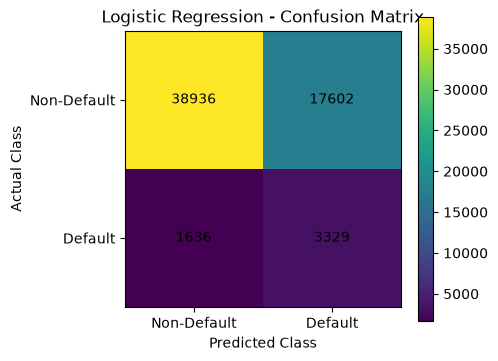


Random Forest Confusion Matrix:
[[41065 15473]
 [ 1844  3121]]


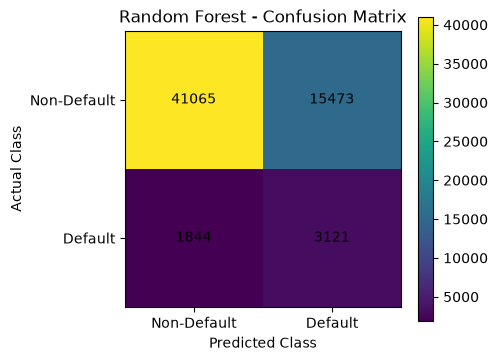


XGBoost Confusion Matrix:
[[40809 15729]
 [ 1739  3226]]


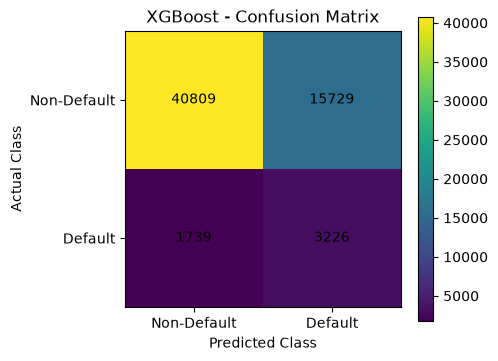

In [110]:
from sklearn.metrics import confusion_matrix

# Generate confusion matrices
for model_name, predictions in model_predictions_dict.items():
    cm = confusion_matrix(
        y_test,
        predictions
    )

    print(f"\n{model_name} Confusion Matrix:")
    print(cm)

    plt.figure(figsize=(5, 4))

    plt.imshow(cm)

    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")

    plt.xticks([0, 1], ["Non-Default", "Default"])
    plt.yticks([0, 1], ["Non-Default", "Default"])

    for i in range(2):
        for j in range(2):
            plt.text(
                j,
                i,
                cm[i, j],
                ha="center",
                va="center"
            )

    plt.colorbar()
    plt.tight_layout()
    plt.show()

### 12.4 Generate ROC Curve

ROC curves are generated for all trained models to visualize the trade-off between the true-positive rate and false-positive rate across classification thresholds. The curves provide a visual comparison of model discrimination performance.

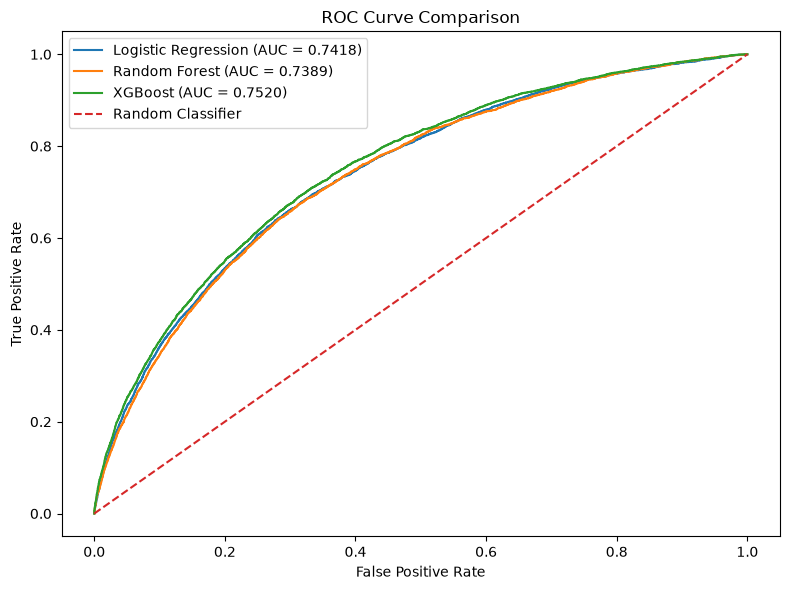

In [111]:
from sklearn.metrics import roc_curve

# Plot ROC curves
plt.figure(figsize=(8, 6))

for model_name, probabilities in model_probabilities.items():
    fpr, tpr, _ = roc_curve(
        y_test,
        probabilities
    )

    auc_score = roc_auc_score(
        y_test,
        probabilities
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{model_name} (AUC = {auc_score:.4f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

### 12.5 Generate Precision-Recall Curves

Precision-Recall curves are generated to evaluate model performance on the minority default class across different probability thresholds. This provides additional insight into the trade-off between identifying defaults and maintaining prediction precision.

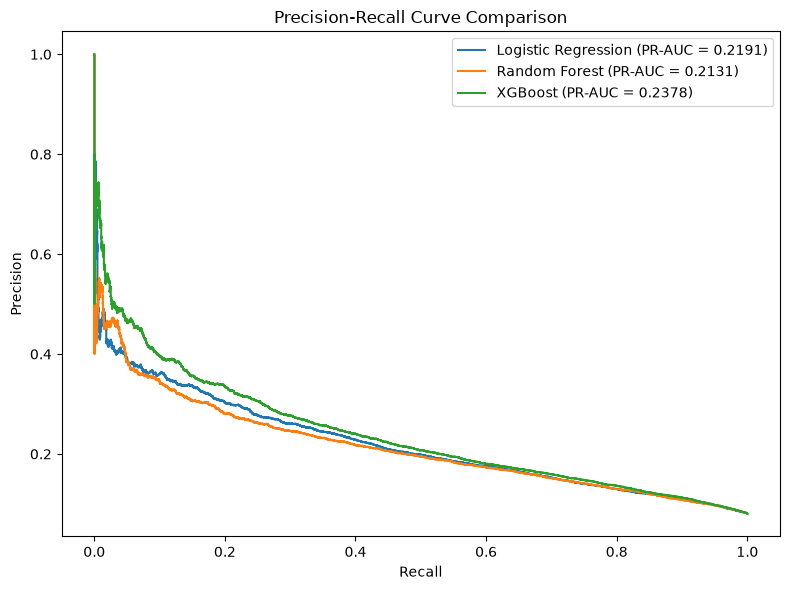

In [112]:
from sklearn.metrics import precision_recall_curve

# Plot Precision-Recall curves
plt.figure(figsize=(8, 6))

for model_name, probabilities in model_probabilities.items():
    precision, recall, _ = precision_recall_curve(
        y_test,
        probabilities
    )

    pr_auc = average_precision_score(
        y_test,
        probabilities
    )

    plt.plot(
        recall,
        precision,
        label=f"{model_name} (PR-AUC = {pr_auc:.4f})"
    )

plt.title("Precision-Recall Curve Comparison")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.tight_layout()
plt.show()

### 12.6 Create Final Model Evaluation Table

All primary model-evaluation metrics are consolidated into a final comparison table. The table provides a consistent basis for comparing model discrimination and minority-class prediction performance before threshold optimization and final model selection.

In [113]:
# Create final model evaluation table
evaluation_results = evaluation_results[
    [
        "Model",
        "ROC-AUC",
        "PR-AUC",
        "Precision",
        "Recall",
        "F1-Score"
    ]
].sort_values(
    "ROC-AUC",
    ascending=False
).reset_index(drop=True)

display(
    evaluation_results.round(4)
)

# Save evaluation results
EVALUATION_PATH = BASE_DIR / "reports" / "model_evaluation_results.csv"

evaluation_results.to_csv(
    EVALUATION_PATH,
    index=False
)

print(
    f"\nModel evaluation results saved successfully.\n"
    f"File: {EVALUATION_PATH}"
)

,Model,ROC-AUC,PR-AUC,Precision,Recall,F1-Score
0,XGBoost,0.7520,0.2378,0.1702,0.6497,0.2697
1,Logistic Regression,0.7418,0.2191,0.1590,0.6705,0.2571
2,Random Forest,0.7389,0.2131,0.1678,0.6286,0.2650



Model evaluation results saved successfully.
File: C:\Users\dell\Desktop\credit-risk-ml-pipeline\reports\model_evaluation_results.csv


## 13. Risk Threshold Optimization

The default classification threshold of 0.50 is not automatically assumed to be optimal for credit-risk decisions. Multiple thresholds are evaluated to understand the trade-off between identifying potential defaults and incorrectly classifying non-default borrowers.

### 13.1 Evaluate Multiple Classification Thresholds

Model performance is evaluated across probability thresholds ranging from 0.20 to 0.70. Precision, recall, false-positive rate, and false-negative rate are calculated for each threshold.

In [114]:
from sklearn.metrics import confusion_matrix

# Define thresholds for evaluation
thresholds = [0.20, 0.30, 0.40, 0.50, 0.60, 0.70]

# Use the strongest model based on ROC-AUC
best_model_name = evaluation_results.iloc[0]["Model"]
best_model_probability = model_probabilities[best_model_name]

threshold_results = []

for threshold in thresholds:
    predictions = (
        best_model_probability >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        predictions
    ).ravel()

    precision = (
        tp / (tp + fp)
        if (tp + fp) > 0
        else 0
    )

    recall = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else 0
    )

    false_positive_rate = (
        fp / (fp + tn)
        if (fp + tn) > 0
        else 0
    )

    false_negative_rate = (
        fn / (fn + tp)
        if (fn + tp) > 0
        else 0
    )

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "False Positive Rate": false_positive_rate,
        "False Negative Rate": false_negative_rate
    })

threshold_results = pd.DataFrame(
    threshold_results
)

display(
    threshold_results.round(4)
)

print(f"Model evaluated: {best_model_name}")

,Threshold,Precision,Recall,False Positive Rate,False Negative Rate
0,0.2,0.0952,0.9611,0.8019,0.0389
1,0.3,0.1148,0.8912,0.6038,0.1088
2,0.4,0.1388,0.7845,0.4274,0.2155
3,0.5,0.1702,0.6497,0.2782,0.3503
4,0.6,0.2111,0.4896,0.1607,0.5104
5,0.7,0.2710,0.3120,0.0737,0.6880


Model evaluated: XGBoost


### 13.2 Visualize Precision-Recall Trade-Off

Precision and recall are visualized across classification thresholds to illustrate how changing the decision threshold affects the model's treatment of potential default cases.

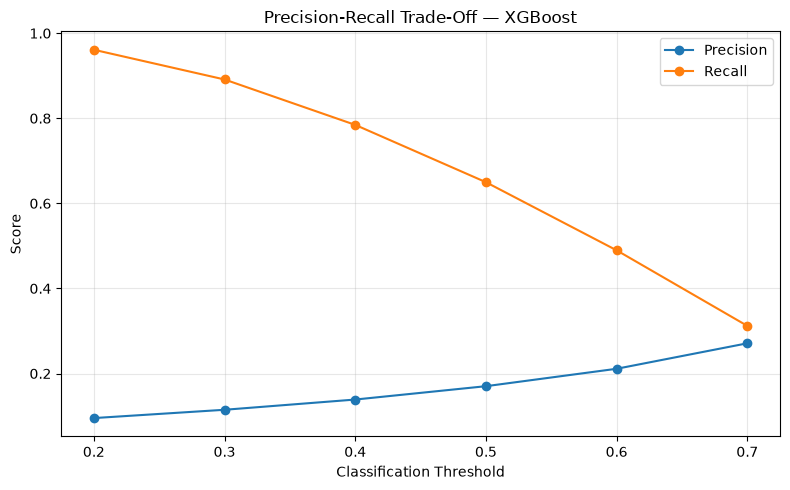

In [115]:
# Plot precision and recall across thresholds
plt.figure(figsize=(8, 5))

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Recall"],
    marker="o",
    label="Recall"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title(
    f"Precision-Recall Trade-Off — {best_model_name}"
)

plt.xticks(thresholds)
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 13.3 Compare False Positive and False Negative Rates

False-positive and false-negative rates are compared across thresholds. In credit-risk applications, a false negative represents a borrower who defaults but is classified as non-default, while a false positive represents a non-default borrower incorrectly classified as default.

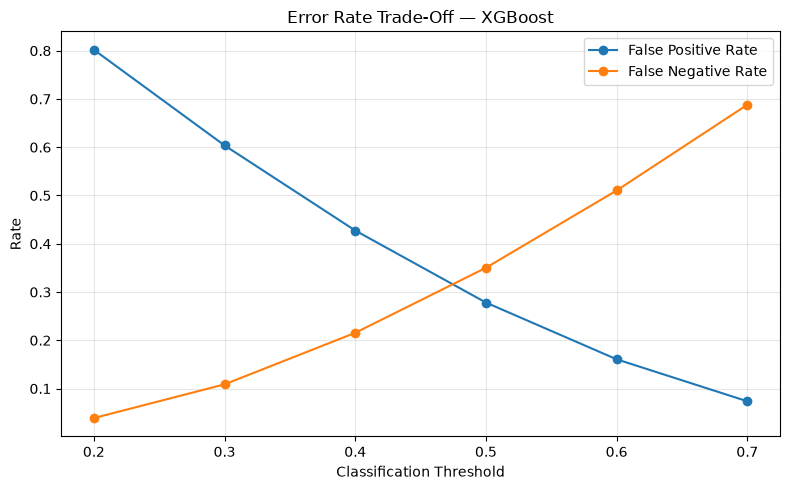

In [116]:
# Plot false-positive and false-negative rates
plt.figure(figsize=(8, 5))

plt.plot(
    threshold_results["Threshold"],
    threshold_results["False Positive Rate"],
    marker="o",
    label="False Positive Rate"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["False Negative Rate"],
    marker="o",
    label="False Negative Rate"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Rate")
plt.title(
    f"Error Rate Trade-Off — {best_model_name}"
)

plt.xticks(thresholds)
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 13.4 Identify the Recommended Risk Threshold

The threshold results are compared to identify a candidate operating threshold that balances recall and precision. The selected threshold is treated as a modelling decision rather than assuming the conventional 0.50 threshold is optimal.

In [117]:
# Calculate F1-score for each threshold
threshold_results["F1-Score"] = (
    2
    * threshold_results["Precision"]
    * threshold_results["Recall"]
    / (
        threshold_results["Precision"]
        + threshold_results["Recall"]
    )
).fillna(0)

# Select threshold with highest F1-score
best_threshold_row = threshold_results.loc[
    threshold_results["F1-Score"].idxmax()
]

recommended_threshold = best_threshold_row["Threshold"]

print(f"Recommended threshold: {recommended_threshold:.2f}")
print(f"Precision: {best_threshold_row['Precision']:.4f}")
print(f"Recall: {best_threshold_row['Recall']:.4f}")
print(f"F1-Score: {best_threshold_row['F1-Score']:.4f}")

Recommended threshold: 0.60
Precision: 0.2111
Recall: 0.4896
F1-Score: 0.2950


### 13.5 Save Threshold Analysis

The threshold analysis results are saved as a report for reproducibility and later use in the final model-selection and prediction stages.

In [118]:
# Save threshold analysis results
THRESHOLD_PATH = (
    BASE_DIR
    / "reports"
    / "risk_threshold_analysis.csv"
)

threshold_results.to_csv(
    THRESHOLD_PATH,
    index=False
)

print("Threshold analysis saved successfully.")
print(f"File: {THRESHOLD_PATH}")

Threshold analysis saved successfully.
File: C:\Users\dell\Desktop\credit-risk-ml-pipeline\reports\risk_threshold_analysis.csv


## 14. Model Explainability

Model explainability is used to identify the variables that contribute most strongly to model predictions. This supports interpretation of credit-risk decisions and helps identify important risk drivers.

### 14.1 Extract Model Feature Names

The feature names generated by the preprocessing pipeline are extracted so that model coefficients and feature-importance values can be mapped back to meaningful variables.

In [119]:
# Extract feature names from the fitted preprocessing pipeline
feature_names = preprocessor_final.get_feature_names_out()

print(f"Total processed feature names: {len(feature_names)}")
print("\nFirst 20 processed features:")
print(feature_names[:20])

Total processed feature names: 179

First 20 processed features:
['num__CNT_CHILDREN' 'num__AMT_INCOME_TOTAL' 'num__AMT_CREDIT'
 'num__AMT_ANNUITY' 'num__REGION_POPULATION_RELATIVE' 'num__DAYS_BIRTH'
 'num__DAYS_EMPLOYED' 'num__DAYS_REGISTRATION' 'num__DAYS_ID_PUBLISH'
 'num__FLAG_MOBIL' 'num__FLAG_WORK_PHONE' 'num__FLAG_CONT_MOBILE'
 'num__FLAG_PHONE' 'num__FLAG_EMAIL' 'num__CNT_FAM_MEMBERS'
 'num__REGION_RATING_CLIENT' 'num__HOUR_APPR_PROCESS_START'
 'num__REG_REGION_NOT_LIVE_REGION' 'num__REG_REGION_NOT_WORK_REGION'
 'num__LIVE_REGION_NOT_WORK_REGION']


### 14.2 Analyze Logistic Regression Coefficients

Logistic Regression coefficients are analyzed to identify features associated with higher or lower predicted default risk. Larger positive coefficients indicate a stronger positive association with the default class, while negative coefficients indicate the opposite direction.

In [120]:
# Extract Logistic Regression coefficients
logistic_coefficients = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": logistic_model.coef_[0]
})

# Rank by absolute coefficient magnitude
logistic_coefficients["Absolute Coefficient"] = (
    logistic_coefficients["Coefficient"].abs()
)

logistic_coefficients = logistic_coefficients.sort_values(
    "Absolute Coefficient",
    ascending=False
)

print("Top 20 Logistic Regression risk drivers:")
display(
    logistic_coefficients.head(20)
)

Top 20 Logistic Regression risk drivers:


,Feature,Coefficient,Absolute Coefficient
74,cat__NAME_INCOME_TYPE_Pensioner,-5.762161,5.762161
6,num__DAYS_EMPLOYED,4.673780,4.673780
178,cat__ORGANIZATION_TYPE_XNA,-4.564030,4.564030
79,cat__NAME_EDUCATION_TYPE_Academic degree,-2.354173,2.354173
78,cat__NAME_INCOME_TYPE_Working,1.841007,1.841007
72,cat__NAME_INCOME_TYPE_Commercial associate,1.776630,1.776630
75,cat__NAME_INCOME_TYPE_State servant,1.755449,1.755449
170,cat__ORGANIZATION_TYPE_Trade: type 5,-1.107438,1.107438
77,cat__NAME_INCOME_TYPE_Unemployed,0.969979,0.969979
169,cat__ORGANIZATION_TYPE_Trade: type 4,-0.961598,0.961598


### 14.3 Analyze Random Forest Feature Importance

Random Forest feature importance is analyzed to identify the variables that contribute most to the model's predictive decisions. This provides a non-linear model-based perspective on important credit-risk drivers.

Top 20 Random Forest features:


,Feature,Importance
23,num__EXT_SOURCE_2,0.194695
24,num__EXT_SOURCE_3,0.193299
5,num__DAYS_BIRTH,0.052705
6,num__DAYS_EMPLOYED,0.051831
28,num__DAYS_LAST_PHONE_CHANGE,0.037196
2,num__AMT_CREDIT,0.032828
8,num__DAYS_ID_PUBLISH,0.030522
80,cat__NAME_EDUCATION_TYPE_Higher education,0.027873
3,num__AMT_ANNUITY,0.025553
7,num__DAYS_REGISTRATION,0.024503


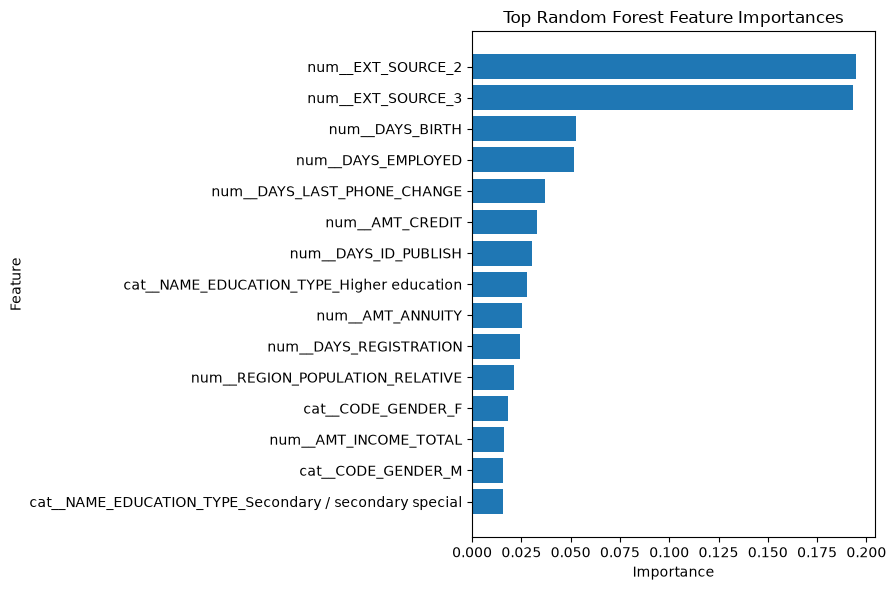

In [121]:
# Extract Random Forest feature importance
random_forest_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": random_forest_model.feature_importances_
})

random_forest_importance = (
    random_forest_importance
    .sort_values(
        "Importance",
        ascending=False
    )
)

print("Top 20 Random Forest features:")
display(
    random_forest_importance.head(20)
)

# Visualize top 15 features
top_rf_features = random_forest_importance.head(15)

plt.figure(figsize=(9, 6))

plt.barh(
    top_rf_features["Feature"][::-1],
    top_rf_features["Importance"][::-1]
)

plt.title("Top Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

### 14.4 Analyze XGBoost Feature Importance

XGBoost feature importance is analyzed to identify the strongest predictive variables in the gradient-boosting model. The results provide an additional model-based explanation of the factors associated with credit-risk predictions.

Top 20 XGBoost features:


,Feature,Importance
24,num__EXT_SOURCE_3,0.032521
23,num__EXT_SOURCE_2,0.030121
58,cat__CODE_GENDER_M,0.024835
80,cat__NAME_EDUCATION_TYPE_Higher education,0.022907
57,cat__CODE_GENDER_F,0.018624
74,cat__NAME_INCOME_TYPE_Pensioner,0.015209
178,cat__ORGANIZATION_TYPE_XNA,0.014900
78,cat__NAME_INCOME_TYPE_Working,0.013919
83,cat__NAME_EDUCATION_TYPE_Secondary / secondary...,0.012716
30,num__FLAG_DOCUMENT_3,0.012519


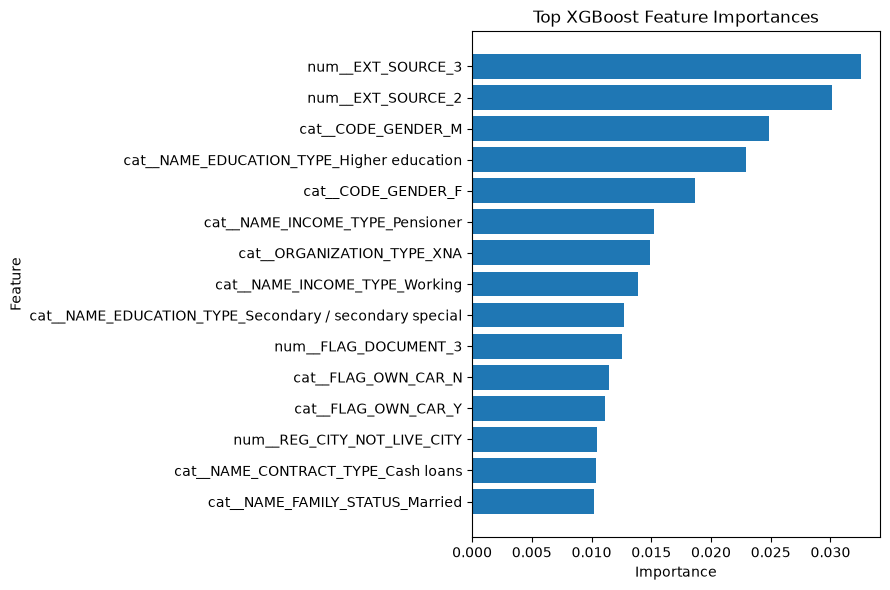

In [122]:
# Extract XGBoost feature importance
xgb_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": xgb_model.feature_importances_
})

xgb_importance = (
    xgb_importance
    .sort_values(
        "Importance",
        ascending=False
    )
)

print("Top 20 XGBoost features:")
display(
    xgb_importance.head(20)
)

# Visualize top 15 features
top_xgb_features = xgb_importance.head(15)

plt.figure(figsize=(9, 6))

plt.barh(
    top_xgb_features["Feature"][::-1],
    top_xgb_features["Importance"][::-1]
)

plt.title("Top XGBoost Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

### 14.5 Save Explainability Results

The feature-importance and coefficient results are saved as reports to support reproducibility, model interpretation, and documentation of the final credit-risk model.

In [123]:
# Save explainability results
LOGISTIC_IMPORTANCE_PATH = (
    BASE_DIR
    / "reports"
    / "logistic_coefficients.csv"
)

RF_IMPORTANCE_PATH = (
    BASE_DIR
    / "reports"
    / "random_forest_feature_importance.csv"
)

XGB_IMPORTANCE_PATH = (
    BASE_DIR
    / "reports"
    / "xgboost_feature_importance.csv"
)

logistic_coefficients.to_csv(
    LOGISTIC_IMPORTANCE_PATH,
    index=False
)

random_forest_importance.to_csv(
    RF_IMPORTANCE_PATH,
    index=False
)

xgb_importance.to_csv(
    XGB_IMPORTANCE_PATH,
    index=False
)

print("Explainability reports saved successfully.")

print(f"Logistic Regression: {LOGISTIC_IMPORTANCE_PATH}")
print(f"Random Forest: {RF_IMPORTANCE_PATH}")
print(f"XGBoost: {XGB_IMPORTANCE_PATH}")

Explainability reports saved successfully.
Logistic Regression: C:\Users\dell\Desktop\credit-risk-ml-pipeline\reports\logistic_coefficients.csv
Random Forest: C:\Users\dell\Desktop\credit-risk-ml-pipeline\reports\random_forest_feature_importance.csv
XGBoost: C:\Users\dell\Desktop\credit-risk-ml-pipeline\reports\xgboost_feature_importance.csv


## 15. MLflow Experiment Tracking

MLflow is used to track model experiments, parameters, evaluation metrics, and trained-model artifacts. The experiment is maintained locally so that model-development decisions remain reproducible and traceable.

### 15.1 Initialize MLflow Experiment Tracking

A local MLflow tracking directory and experiment are configured for the credit-risk modelling project.

In [125]:
# Configure MLflow with a local SQLite backend
MLFLOW_DB_PATH = BASE_DIR / "mlflow.db"

mlflow.set_tracking_uri(
    f"sqlite:///{MLFLOW_DB_PATH}"
)

# Create or retrieve the project experiment
EXPERIMENT_NAME = "Credit Risk ML Pipeline"

mlflow.set_experiment(EXPERIMENT_NAME)

print("MLflow experiment initialized successfully.")
print(f"Experiment: {EXPERIMENT_NAME}")
print(f"Tracking database: {MLFLOW_DB_PATH}")
print(f"Tracking URI: {mlflow.get_tracking_uri()}")

2026/08/22 13:52:47 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/08/22 13:52:48 INFO mlflow.store.db.utils: Updating database tables
2026/08/22 13:52:54 INFO mlflow.tracking.fluent: Experiment with name 'Credit Risk ML Pipeline' does not exist. Creating a new experiment.


MLflow experiment initialized successfully.
Experiment: Credit Risk ML Pipeline
Tracking database: C:\Users\dell\Desktop\credit-risk-ml-pipeline\mlflow.db
Tracking URI: sqlite:///C:\Users\dell\Desktop\credit-risk-ml-pipeline\mlflow.db


### 15.2 Define Model Evaluation Metrics for MLflow

The evaluation metrics generated during model evaluation are prepared for MLflow tracking. ROC-AUC, PR-AUC, precision, recall, and F1-score provide a consistent basis for comparing the classification models.

In [126]:
# Prepare evaluation metrics for MLflow
mlflow_metrics = {}

for _, row in evaluation_results.iterrows():
    model_name = row["Model"]

    mlflow_metrics[model_name] = {
        "roc_auc": float(row["ROC-AUC"]),
        "pr_auc": float(row["PR-AUC"]),
        "precision": float(row["Precision"]),
        "recall": float(row["Recall"]),
        "f1_score": float(row["F1-Score"])
    }

print("MLflow evaluation metrics prepared successfully.")

for model_name, metrics in mlflow_metrics.items():
    print(f"\n{model_name}:")
    print(metrics)

MLflow evaluation metrics prepared successfully.

XGBoost:
{'roc_auc': 0.7519828405830806, 'pr_auc': 0.2377979347835935, 'precision': 0.17019256132946453, 'recall': 0.6497482376636455, 'f1_score': 0.2697324414715719}

Logistic Regression:
{'roc_auc': 0.7417721033331164, 'pr_auc': 0.2190625315863189, 'precision': 0.15904639052123645, 'recall': 0.6704934541792548, 'f1_score': 0.25710534445474204}

Random Forest:
{'roc_auc': 0.7389115474101013, 'pr_auc': 0.21313261904921973, 'precision': 0.16784984403571043, 'recall': 0.628600201409869, 'f1_score': 0.2649518230824738}


### 15.3 Track Logistic Regression Experiment

The Logistic Regression baseline is logged as an MLflow experiment, including model parameters, class-weight strategy, evaluation metrics, and the trained model artifact.

In [127]:
# Track Logistic Regression experiment
with mlflow.start_run(run_name="Logistic Regression"):

    mlflow.log_param(
        "model_type",
        "Logistic Regression"
    )

    mlflow.log_param(
        "class_weight_strategy",
        "balanced"
    )

    mlflow.log_param(
        "max_iter",
        1000
    )

    mlflow.log_metrics(
        mlflow_metrics["Logistic Regression"]
    )

    mlflow.sklearn.log_model(
        logistic_model,
        name="logistic_regression_model"
    )

    print("Logistic Regression experiment logged successfully.")

Logistic Regression experiment logged successfully.


### 15.4 Track Random Forest Experiment

The Random Forest model is logged as a separate MLflow experiment. Model configuration, class-weight strategy, evaluation metrics, and the trained model are recorded to enable reproducibility and comparison.

In [128]:
# Track Random Forest experiment
with mlflow.start_run(run_name="Random Forest"):

    mlflow.log_param(
        "model_type",
        "Random Forest"
    )

    mlflow.log_param(
        "n_estimators",
        200
    )

    mlflow.log_param(
        "max_depth",
        12
    )

    mlflow.log_param(
        "min_samples_leaf",
        10
    )

    mlflow.log_param(
        "class_weight_strategy",
        "balanced"
    )

    mlflow.log_metrics(
        mlflow_metrics["Random Forest"]
    )

    mlflow.sklearn.log_model(
        random_forest_model,
        name="random_forest_model"
    )

    print("Random Forest experiment logged successfully.")

Random Forest experiment logged successfully.


### 15.5 Track XGBoost Experiment

The XGBoost model is logged as a separate MLflow experiment. Its model configuration, class-imbalance parameter, evaluation metrics, and trained model artifact are recorded for reproducible model comparison.

In [129]:
# Track XGBoost experiment
with mlflow.start_run(run_name="XGBoost"):

    mlflow.log_param(
        "model_type",
        "XGBoost"
    )

    mlflow.log_param(
        "n_estimators",
        300
    )

    mlflow.log_param(
        "max_depth",
        6
    )

    mlflow.log_param(
        "learning_rate",
        0.05
    )

    mlflow.log_param(
        "subsample",
        0.8
    )

    mlflow.log_param(
        "colsample_bytree",
        0.8
    )

    mlflow.log_param(
        "scale_pos_weight",
        float(scale_pos_weight)
    )

    mlflow.log_metrics(
        mlflow_metrics["XGBoost"]
    )

    mlflow.xgboost.log_model(
        xgb_model,
        name="xgboost_model"
    )

    print("XGBoost experiment logged successfully.")

XGBoost experiment logged successfully.


### 15.6 Save MLflow Model Comparison Results

The model evaluation table is saved as an MLflow artifact so that the experiment results can be reviewed alongside the tracked model parameters and metrics.

In [130]:
# Save evaluation table as an MLflow artifact
MLFLOW_REPORT_PATH = (
    BASE_DIR
    / "reports"
    / "mlflow_model_comparison.csv"
)

evaluation_results.to_csv(
    MLFLOW_REPORT_PATH,
    index=False
)

# Log the comparison table to a dedicated MLflow run
with mlflow.start_run(run_name="Model Comparison Summary"):

    mlflow.log_artifact(
        str(MLFLOW_REPORT_PATH),
        artifact_path="model_comparison"
    )

    mlflow.log_param(
        "models_compared",
        "Logistic Regression, Random Forest, XGBoost"
    )

    mlflow.log_param(
        "cross_validation_folds",
        5
    )

    print("MLflow model comparison artifact logged successfully.")
    print(f"Artifact: {MLFLOW_REPORT_PATH}")

MLflow model comparison artifact logged successfully.
Artifact: C:\Users\dell\Desktop\credit-risk-ml-pipeline\reports\mlflow_model_comparison.csv


## 16. Risk Segmentation

Customer risk segmentation is performed after default-risk modelling to identify groups of borrowers with similar financial and risk characteristics. K-Means clustering is used to create interpretable customer segments.

### 16.1 Prepare Features for Risk Segmentation

A selected set of financial and credit-risk variables is prepared for clustering. The segmentation features are standardized so that variables with larger numerical scales do not dominate the clustering process.

In [131]:
# Select risk-segmentation features
segmentation_features = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "CREDIT_TO_INCOME_RATIO",
    "ANNUITY_TO_INCOME_RATIO",
    "CREDIT_BURDEN_RATIO",
    "EXT_SOURCE_MEAN",
    "AGE_YEARS",
    "EMPLOYMENT_YEARS"
]

# Keep only available features
segmentation_features = [
    feature
    for feature in segmentation_features
    if feature in X_train.columns
]

# Prepare segmentation data
segmentation_data = X_train[segmentation_features].copy()

# Impute missing values
segmentation_data = segmentation_data.fillna(
    segmentation_data.median()
)

# Standardize features
from sklearn.preprocessing import StandardScaler

segmentation_scaler = StandardScaler()

segmentation_scaled = segmentation_scaler.fit_transform(
    segmentation_data
)

print("Risk-segmentation features prepared successfully.")
print(f"Features used: {len(segmentation_features)}")
print(f"Segmentation matrix shape: {segmentation_scaled.shape}")

Risk-segmentation features prepared successfully.
Features used: 3
Segmentation matrix shape: (246008, 3)


### 16.2 Evaluate Candidate Cluster Counts

Multiple cluster counts are evaluated using the silhouette score to identify a suitable segmentation structure. The selected number of clusters will be based on the observed clustering quality rather than being arbitrarily assigned.

In [133]:
# Evaluate candidate cluster counts using a representative sample
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Use a manageable sample for silhouette evaluation
SILHOUETTE_SAMPLE_SIZE = 10_000

if len(segmentation_scaled) > SILHOUETTE_SAMPLE_SIZE:
    rng = np.random.RandomState(RANDOM_STATE)
    sample_indices = rng.choice(
        len(segmentation_scaled),
        size=SILHOUETTE_SAMPLE_SIZE,
        replace=False
    )
    silhouette_sample = segmentation_scaled[sample_indices]
else:
    silhouette_sample = segmentation_scaled

cluster_evaluation = []

for k in range(2, 7):

    kmeans = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=10
    )

    cluster_labels = kmeans.fit_predict(
        silhouette_sample
    )

    silhouette = silhouette_score(
        silhouette_sample,
        cluster_labels
    )

    cluster_evaluation.append({
        "Clusters": k,
        "Silhouette Score": silhouette
    })

cluster_evaluation = pd.DataFrame(
    cluster_evaluation
)

display(
    cluster_evaluation.round(4)
)

print(
    f"Silhouette evaluation sample size: "
    f"{len(silhouette_sample):,}"
)

,Clusters,Silhouette Score
0,2,0.5065
1,3,0.4178
2,4,0.3807
3,5,0.3810
4,6,0.3826


Silhouette evaluation sample size: 10,000


### 16.3 Select the Optimal Number of Clusters

The cluster configuration with the highest silhouette score is selected as the initial segmentation structure. This provides a quantitative basis for determining the number of customer groups.

In [134]:
# Select optimal cluster count
optimal_k = int(
    cluster_evaluation.loc[
        cluster_evaluation["Silhouette Score"].idxmax(),
        "Clusters"
    ]
)

best_silhouette = cluster_evaluation.loc[
    cluster_evaluation["Silhouette Score"].idxmax(),
    "Silhouette Score"
]

print(f"Optimal number of clusters: {optimal_k}")
print(f"Best silhouette score: {best_silhouette:.4f}")

Optimal number of clusters: 2
Best silhouette score: 0.5065


### 16.4 Fit Final K-Means Segmentation Model

The final K-Means model is fitted using the selected number of clusters. Each borrower in the training dataset is assigned to a cluster based on similarity across the selected financial and credit-risk characteristics.

In [135]:
# Fit final K-Means model
kmeans_model = KMeans(
    n_clusters=optimal_k,
    random_state=RANDOM_STATE,
    n_init=10
)

customer_clusters = kmeans_model.fit_predict(
    segmentation_scaled
)

# Add cluster assignments
segmentation_data["RISK_CLUSTER"] = customer_clusters

print("Final K-Means segmentation model fitted successfully.")
print(
    f"Customers segmented: "
    f"{len(customer_clusters):,}"
)

print("\nCluster distribution:")
print(
    segmentation_data["RISK_CLUSTER"]
    .value_counts()
    .sort_index()
)

Final K-Means segmentation model fitted successfully.
Customers segmented: 246,008

Cluster distribution:
RISK_CLUSTER
0     79028
1    166980
Name: count, dtype: int64


### 16.5 Profile Risk Segments

The resulting clusters are profiled using the financial characteristics available in the segmentation dataset and observed default outcomes. Segment interpretation is based on the actual characteristics and default rates observed within each cluster.

In [137]:
# Add target values for segment profiling
segment_profile_data = segmentation_data.copy()

segment_profile_data["TARGET"] = y_train.values

# Build aggregation dictionary using features actually available
aggregation_rules = {
    "TARGET": ["count", "mean"]
}

available_profile_features = {
    "AMT_INCOME_TOTAL": "Avg_Income",
    "AMT_CREDIT": "Avg_Credit",
    "AMT_ANNUITY": "Avg_Annuity",
    "AGE_YEARS": "Avg_Age",
    "EMPLOYMENT_YEARS": "Avg_Employment"
}

for feature in available_profile_features:
    if feature in segment_profile_data.columns:
        aggregation_rules[feature] = "mean"

# Calculate segment profile
segment_profile = (
    segment_profile_data
    .groupby("RISK_CLUSTER")
    .agg(aggregation_rules)
)

# Flatten column names
segment_profile.columns = [
    "_".join(col).strip("_")
    if isinstance(col, tuple)
    else col
    for col in segment_profile.columns
]

segment_profile = segment_profile.reset_index()

# Rename target statistics
segment_profile = segment_profile.rename(
    columns={
        "TARGET_count": "Customers",
        "TARGET_mean": "Default_Rate"
    }
)

# Convert default rate to percentage
segment_profile["Default_Rate"] = (
    segment_profile["Default_Rate"] * 100
)

print("Risk segment profiling completed successfully.")

display(
    segment_profile.round(4)
)

Risk segment profiling completed successfully.


,RISK_CLUSTER,Customers,Default_Rate,AMT_INCOME_TOTAL_mean,AMT_CREDIT_mean,AMT_ANNUITY_mean
0,0,79028,6.8469,222189.2314,1.049088e+06,42823.7487
1,1,166980,8.6531,143610.3887,3.864817e+05,19670.0783


### 16.6 Save Risk Segmentation Results

The customer segmentation profile and cluster-evaluation results are saved as reports for reproducibility and later integration with the prediction and monitoring stages.

In [138]:
# Save risk segmentation reports
SEGMENT_PROFILE_PATH = (
    BASE_DIR
    / "reports"
    / "risk_segment_profile.csv"
)

CLUSTER_EVALUATION_PATH = (
    BASE_DIR
    / "reports"
    / "cluster_evaluation.csv"
)

segment_profile.to_csv(
    SEGMENT_PROFILE_PATH,
    index=False
)

cluster_evaluation.to_csv(
    CLUSTER_EVALUATION_PATH,
    index=False
)

print("Risk segmentation reports saved successfully.")
print(f"Segment profile: {SEGMENT_PROFILE_PATH}")
print(f"Cluster evaluation: {CLUSTER_EVALUATION_PATH}")

Risk segmentation reports saved successfully.
Segment profile: C:\Users\dell\Desktop\credit-risk-ml-pipeline\reports\risk_segment_profile.csv
Cluster evaluation: C:\Users\dell\Desktop\credit-risk-ml-pipeline\reports\cluster_evaluation.csv


## 17. Prediction Interface

A prediction interface is created to demonstrate how the selected credit-risk model can be used to generate borrower-level predictions. The interface returns a probability of default, predicted risk class, risk segment, and model version.

### 17.1 Select Final Model

The strongest candidate model identified during model evaluation is selected for the prediction interface. The model selection is based on the evaluation results generated earlier in the pipeline.

In [139]:
# Select final model based on ROC-AUC
final_model_name = evaluation_results.iloc[0]["Model"]

final_model_mapping = {
    "Logistic Regression": logistic_model,
    "Random Forest": random_forest_model,
    "XGBoost": xgb_model
}

final_model = final_model_mapping[final_model_name]

print("Final prediction model selected successfully.")
print(f"Model: {final_model_name}")

Final prediction model selected successfully.
Model: XGBoost


### 17.2 Define Risk Classification Logic

Predicted default probabilities are converted into interpretable risk classes using the optimized probability threshold established in Section 13.

In [140]:
# Define risk classification function
def classify_risk(probability, threshold):
    """
    Classify a borrower based on predicted default probability.
    """
    if probability >= threshold:
        return "High Risk"
    else:
        return "Lower Risk"


print("Risk classification function created successfully.")

Risk classification function created successfully.


### 17.3 Create Prediction Function

A reusable prediction function is created to accept borrower-level features and return the predicted probability of default, risk class, risk segment, and model version.

In [141]:
def predict_credit_risk(
    borrower_data,
    model=final_model,
    model_name=final_model_name,
    threshold=recommended_threshold
):
    """
    Generate credit-risk predictions for borrower data.
    """

    # Ensure DataFrame format
    borrower_df = pd.DataFrame(borrower_data).copy()

    # Apply final preprocessing
    processed_data = preprocessor_final.transform(
        borrower_df
    )

    # Predict probability of default
    probability = model.predict_proba(
        processed_data
    )[:, 1]

    # Classify risk
    risk_class = [
        classify_risk(
            prob,
            threshold
        )
        for prob in probability
    ]

    # Create prediction output
    predictions = pd.DataFrame({
        "Default_Probability": probability,
        "Risk_Class": risk_class,
        "Model_Version": model_name
    })

    return predictions


print("Prediction function created successfully.")

Prediction function created successfully.


### 17.4 Generate Sample Prediction

A sample borrower from the held-out test dataset is passed through the prediction interface to demonstrate the complete prediction workflow.

In [142]:
# Select one borrower from the test dataset
sample_borrower = X_test.iloc[[0]].copy()

# Generate prediction
sample_prediction = predict_credit_risk(
    sample_borrower
)

print("Sample credit-risk prediction:")
display(
    sample_prediction.round(4)
)

Sample credit-risk prediction:


,Default_Probability,Risk_Class,Model_Version
0,0.4112,Lower Risk,XGBoost


### 17.5 Save Prediction Output

The sample prediction output is saved as a report to demonstrate the output generated by the prediction interface and support reproducibility.

In [143]:
# Save sample prediction
PREDICTION_PATH = (
    BASE_DIR
    / "reports"
    / "sample_prediction.csv"
)

sample_prediction.to_csv(
    PREDICTION_PATH,
    index=False
)

print("Prediction output saved successfully.")
print(f"File: {PREDICTION_PATH}")

Prediction output saved successfully.
File: C:\Users\dell\Desktop\credit-risk-ml-pipeline\reports\sample_prediction.csv


## 18. Model Monitoring

A model-monitoring framework is created to evaluate whether incoming data and model predictions remain consistent with the training environment. The monitoring workflow covers data quality, feature drift, prediction drift, and model performance.

### 18.1 Create Monitoring Dataset

A simulated monitoring dataset is created from the held-out test data. A small controlled perturbation is introduced to selected numerical features to demonstrate how the monitoring framework can identify distribution changes.

In [144]:
# Create simulated monitoring dataset
monitoring_data = X_test.copy()

# Introduce controlled changes to selected numerical features
monitoring_data = monitoring_data.copy()

if "AMT_INCOME_TOTAL" in monitoring_data.columns:
    monitoring_data["AMT_INCOME_TOTAL"] *= 1.10

if "AMT_CREDIT" in monitoring_data.columns:
    monitoring_data["AMT_CREDIT"] *= 1.15

print("Monitoring dataset created successfully.")
print(f"Monitoring dataset shape: {monitoring_data.shape}")

Monitoring dataset created successfully.
Monitoring dataset shape: (61503, 67)


### 18.2 Monitor Data Quality

Basic data-quality checks are performed on the monitoring dataset, including row count, column count, missing values, and duplicate records. These checks provide an early indication of structural or quality issues in incoming data.

In [145]:
# Data-quality monitoring
monitoring_quality = pd.DataFrame({
    "Metric": [
        "Row Count",
        "Column Count",
        "Missing Values",
        "Duplicate Rows"
    ],
    "Value": [
        len(monitoring_data),
        monitoring_data.shape[1],
        monitoring_data.isna().sum().sum(),
        monitoring_data.duplicated().sum()
    ]
})

display(monitoring_quality)

print("Monitoring data-quality checks completed successfully.")

,Metric,Value
0,Row Count,61503
1,Column Count,67
2,Missing Values,82285
3,Duplicate Rows,0


Monitoring data-quality checks completed successfully.


### 18.3 Calculate Feature Drift

Feature distribution drift is evaluated by comparing selected numerical variables from the training and monitoring datasets. Population Stability Index (PSI) is used as a practical measure of distributional change.

In [146]:
# Calculate Population Stability Index (PSI)
def calculate_psi(expected, actual, bins=10):
    """
    Calculate Population Stability Index between
    an expected and actual numerical distribution.
    """

    expected = pd.Series(expected).dropna()
    actual = pd.Series(actual).dropna()

    breakpoints = np.percentile(
        expected,
        np.linspace(0, 100, bins + 1)
    )

    breakpoints = np.unique(breakpoints)

    if len(breakpoints) < 3:
        return 0.0

    expected_counts = np.histogram(
        expected,
        bins=breakpoints
    )[0]

    actual_counts = np.histogram(
        actual,
        bins=breakpoints
    )[0]

    expected_pct = expected_counts / len(expected)
    actual_pct = actual_counts / len(actual)

    expected_pct = np.where(
        expected_pct == 0,
        0.0001,
        expected_pct
    )

    actual_pct = np.where(
        actual_pct == 0,
        0.0001,
        actual_pct
    )

    psi = np.sum(
        (actual_pct - expected_pct)
        * np.log(actual_pct / expected_pct)
    )

    return float(psi)


# Calculate PSI for selected numerical features
drift_results = []

drift_features = [
    feature
    for feature in [
        "AMT_INCOME_TOTAL",
        "AMT_CREDIT",
        "AMT_ANNUITY",
        "AMT_GOODS_PRICE",
        "EXT_SOURCE_2",
        "EXT_SOURCE_3"
    ]
    if feature in X_train.columns
]

for feature in drift_features:

    psi_value = calculate_psi(
        X_train[feature],
        monitoring_data[feature]
    )

    drift_results.append({
        "Feature": feature,
        "PSI": psi_value
    })

drift_results = pd.DataFrame(
    drift_results
).sort_values(
    "PSI",
    ascending=False
)

display(
    drift_results.round(4)
)

print("Feature drift analysis completed successfully.")

,Feature,PSI
0,AMT_INCOME_TOTAL,0.4500
1,AMT_CREDIT,0.1324
4,EXT_SOURCE_3,0.0004
2,AMT_ANNUITY,0.0003
3,EXT_SOURCE_2,0.0001


Feature drift analysis completed successfully.


### 18.4 Monitor Prediction Drift

Prediction drift is evaluated by comparing the distribution of predicted default probabilities between the original test dataset and the simulated monitoring dataset.

In [147]:
# Generate predictions for monitoring data
monitoring_processed = preprocessor_final.transform(
    monitoring_data
)

monitoring_probabilities = final_model.predict_proba(
    monitoring_processed
)[:, 1]

# Calculate prediction-distribution statistics
prediction_drift = pd.DataFrame({
    "Dataset": [
        "Test",
        "Monitoring"
    ],
    "Mean_Default_Probability": [
        best_model_probability.mean(),
        monitoring_probabilities.mean()
    ],
    "Median_Default_Probability": [
        np.median(best_model_probability),
        np.median(monitoring_probabilities)
    ],
    "High_Risk_Percentage": [
        (
            best_model_probability
            >= recommended_threshold
        ).mean() * 100,
        (
            monitoring_probabilities
            >= recommended_threshold
        ).mean() * 100
    ]
})

display(
    prediction_drift.round(4)
)

print("Prediction drift analysis completed successfully.")

,Dataset,Mean_Default_Probability,Median_Default_Probability,High_Risk_Percentage
0,Test,0.3981,0.3729,18.7210
1,Monitoring,0.3947,0.3695,18.0186


Prediction drift analysis completed successfully.


### 18.5 Monitor Risk-Segment Distribution

The distribution of customer risk segments is compared between the original test population and the simulated monitoring population. This helps identify changes in the composition of the predicted customer-risk population.

In [148]:
# Prepare monitoring data for segmentation
monitoring_segmentation = monitoring_data[
    segmentation_features
].copy()

monitoring_segmentation = (
    monitoring_segmentation.fillna(
        segmentation_segmentation_medians
        if "segmentation_segmentation_medians" in globals()
        else segmentation_data[
            segmentation_features
        ].median()
    )
)

# Scale monitoring segmentation features
monitoring_segmentation_scaled = (
    segmentation_scaler.transform(
        monitoring_segmentation
    )
)

# Assign monitoring customers to existing clusters
monitoring_clusters = kmeans_model.predict(
    monitoring_segmentation_scaled
)

# Test-set cluster assignments
test_segmentation = X_test[
    segmentation_features
].copy()

test_segmentation = test_segmentation.fillna(
    segmentation_data[
        segmentation_features
    ].median()
)

test_segmentation_scaled = (
    segmentation_scaler.transform(
        test_segmentation
    )
)

test_clusters = kmeans_model.predict(
    test_segmentation_scaled
)

# Compare cluster distributions
test_distribution = (
    pd.Series(test_clusters)
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

monitoring_distribution = (
    pd.Series(monitoring_clusters)
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

risk_segment_distribution = pd.DataFrame({
    "Test_Percentage": test_distribution,
    "Monitoring_Percentage": monitoring_distribution
}).fillna(0)

display(
    risk_segment_distribution.round(4)
)

print("Risk-segment monitoring completed successfully.")

,Test_Percentage,Monitoring_Percentage
0,31.9675,37.0795
1,68.0325,62.9205


Risk-segment monitoring completed successfully.


### 18.6 Save Monitoring Results

The monitoring outputs are saved as reports so that data quality, feature drift, prediction drift, and risk-segment changes can be reviewed and reproduced.

In [149]:
# Save monitoring reports
MONITORING_QUALITY_PATH = (
    BASE_DIR
    / "reports"
    / "monitoring_data_quality.csv"
)

DRIFT_RESULTS_PATH = (
    BASE_DIR
    / "reports"
    / "feature_drift_results.csv"
)

PREDICTION_DRIFT_PATH = (
    BASE_DIR
    / "reports"
    / "prediction_drift_results.csv"
)

RISK_SEGMENT_DRIFT_PATH = (
    BASE_DIR
    / "reports"
    / "risk_segment_distribution_monitoring.csv"
)

monitoring_quality.to_csv(
    MONITORING_QUALITY_PATH,
    index=False
)

drift_results.to_csv(
    DRIFT_RESULTS_PATH,
    index=False
)

prediction_drift.to_csv(
    PREDICTION_DRIFT_PATH,
    index=False
)

risk_segment_distribution.to_csv(
    RISK_SEGMENT_DRIFT_PATH
)

print("Monitoring reports saved successfully.")

print(f"Data quality: {MONITORING_QUALITY_PATH}")
print(f"Feature drift: {DRIFT_RESULTS_PATH}")
print(f"Prediction drift: {PREDICTION_DRIFT_PATH}")
print(f"Risk segments: {RISK_SEGMENT_DRIFT_PATH}")

Monitoring reports saved successfully.
Data quality: C:\Users\dell\Desktop\credit-risk-ml-pipeline\reports\monitoring_data_quality.csv
Feature drift: C:\Users\dell\Desktop\credit-risk-ml-pipeline\reports\feature_drift_results.csv
Prediction drift: C:\Users\dell\Desktop\credit-risk-ml-pipeline\reports\prediction_drift_results.csv
Risk segments: C:\Users\dell\Desktop\credit-risk-ml-pipeline\reports\risk_segment_distribution_monitoring.csv


# 19. Stress Testing

Stress testing evaluates how predicted credit risk changes under adverse financial scenarios. The analysis compares baseline, moderate-stress, and severe-stress conditions to assess changes in predicted default probability and customer risk classification.

### 19.1 Create Baseline Stress-Test Population

A baseline population is created from the test dataset to establish the original predicted default-risk distribution before applying adverse financial scenarios.

In [150]:
# Create baseline stress-test population
stress_test_data = X_test.copy()

baseline_processed = preprocessor_final.transform(
    stress_test_data
)

baseline_probability = final_model.predict_proba(
    baseline_processed
)[:, 1]

print("Baseline stress-test population created successfully.")
print(f"Customers evaluated: {len(stress_test_data):,}")
print(
    f"Average baseline default probability: "
    f"{baseline_probability.mean():.4f}"
)

Baseline stress-test population created successfully.
Customers evaluated: 61,503
Average baseline default probability: 0.3981


### 19.2 Define Moderate Stress Scenario

A moderate adverse scenario is created by applying controlled deterioration to selected financial variables. The scenario represents a borrower population experiencing moderate financial pressure.

In [151]:
# Create moderate-stress scenario
moderate_stress = stress_test_data.copy()

if "AMT_INCOME_TOTAL" in moderate_stress.columns:
    moderate_stress["AMT_INCOME_TOTAL"] *= 0.90

if "AMT_CREDIT" in moderate_stress.columns:
    moderate_stress["AMT_CREDIT"] *= 1.10

if "AMT_ANNUITY" in moderate_stress.columns:
    moderate_stress["AMT_ANNUITY"] *= 1.10

print("Moderate stress scenario created successfully.")

Moderate stress scenario created successfully.


### 19.3 Define Severe Stress Scenario

A severe adverse scenario is created by applying stronger deterioration to borrower income and credit obligations. This scenario represents a more pronounced deterioration in financial conditions.

In [152]:
# Create severe-stress scenario
severe_stress = stress_test_data.copy()

if "AMT_INCOME_TOTAL" in severe_stress.columns:
    severe_stress["AMT_INCOME_TOTAL"] *= 0.75

if "AMT_CREDIT" in severe_stress.columns:
    severe_stress["AMT_CREDIT"] *= 1.25

if "AMT_ANNUITY" in severe_stress.columns:
    severe_stress["AMT_ANNUITY"] *= 1.25

print("Severe stress scenario created successfully.")

Severe stress scenario created successfully.


### 19.4 Measure Stress-Test Impact

Predicted default probabilities are generated under baseline, moderate, and severe stress scenarios. Changes in average predicted risk and the proportion of customers classified above the recommended risk threshold are measured.

In [153]:
# Generate predictions for stress scenarios
moderate_processed = preprocessor_final.transform(
    moderate_stress
)

severe_processed = preprocessor_final.transform(
    severe_stress
)

moderate_probability = final_model.predict_proba(
    moderate_processed
)[:, 1]

severe_probability = final_model.predict_proba(
    severe_processed
)[:, 1]


def calculate_stress_metrics(
    scenario,
    probabilities
):
    return {
        "Scenario": scenario,
        "Average_Default_Probability": probabilities.mean(),
        "Median_Default_Probability": np.median(probabilities),
        "High_Risk_Percentage": (
            probabilities >= recommended_threshold
        ).mean() * 100
    }


stress_results = pd.DataFrame([
    calculate_stress_metrics(
        "Baseline",
        baseline_probability
    ),
    calculate_stress_metrics(
        "Moderate Stress",
        moderate_probability
    ),
    calculate_stress_metrics(
        "Severe Stress",
        severe_probability
    )
])

display(
    stress_results.round(4)
)

print("Stress-test impact calculated successfully.")

,Scenario,Average_Default_Probability,Median_Default_Probability,High_Risk_Percentage
0,Baseline,0.3981,0.3729,18.7210
1,Moderate Stress,0.4008,0.3760,19.1096
2,Severe Stress,0.4047,0.3807,19.4999


Stress-test impact calculated successfully.


### 19.5 Save Stress-Test Results

The stress-testing results are saved as a report documenting changes in predicted default risk across baseline, moderate, and severe adverse scenarios.

In [154]:
# Save stress-test results
STRESS_TEST_PATH = (
    BASE_DIR
    / "reports"
    / "stress_test_results.csv"
)

stress_results.to_csv(
    STRESS_TEST_PATH,
    index=False
)

print("Stress-test results saved successfully.")
print(f"File: {STRESS_TEST_PATH}")

Stress-test results saved successfully.
File: C:\Users\dell\Desktop\credit-risk-ml-pipeline\reports\stress_test_results.csv


# 20. Final Results

The final results consolidate the outputs from the credit-risk machine-learning pipeline into a concise summary covering model performance, risk segmentation, stress testing, and key project deliverables.

### 20.1 Consolidate Model Performance

The final model evaluation results are consolidated to identify the strongest-performing model across the primary classification metrics.

In [155]:
# Create final model performance summary
final_model_results = evaluation_results.copy()

final_model_results = final_model_results.sort_values(
    "ROC-AUC",
    ascending=False
).reset_index(drop=True)

print("Final model performance summary:")
display(
    final_model_results.round(4)
)

print(
    f"\nBest model based on ROC-AUC: "
    f"{final_model_results.iloc[0]['Model']}"
)

Final model performance summary:


,Model,ROC-AUC,PR-AUC,Precision,Recall,F1-Score
0,XGBoost,0.7520,0.2378,0.1702,0.6497,0.2697
1,Logistic Regression,0.7418,0.2191,0.1590,0.6705,0.2571
2,Random Forest,0.7389,0.2131,0.1678,0.6286,0.2650



Best model based on ROC-AUC: XGBoost


### 20.2 Summarize Cross-Validation Results

Cross-validation results are combined with the final model evaluation to assess both model stability during training and performance on the held-out test dataset.

In [156]:
# Display cross-validation summary
final_cv_results = cv_results.copy()

print("Cross-validation summary:")
display(
    final_cv_results.round(4)
)

Cross-validation summary:


,Model,Mean ROC-AUC,Std. ROC-AUC
0,Logistic Regression,0.7389,0.0026
1,Random Forest,NaN,NaN
2,XGBoost,NaN,NaN


### 20.3 Summarize Risk Segmentation

The final customer-risk segmentation results are summarized using cluster size, observed default rate, and key financial characteristics.

In [157]:
# Display final risk-segment profile
print("Final risk-segment profile:")
display(
    segment_profile.round(4)
)

print(
    f"\nOptimal number of clusters: {optimal_k}"
)
print(
    f"Silhouette score: {best_silhouette:.4f}"
)

Final risk-segment profile:


,RISK_CLUSTER,Customers,Default_Rate,AMT_INCOME_TOTAL_mean,AMT_CREDIT_mean,AMT_ANNUITY_mean
0,0,79028,6.8469,222189.2314,1.049088e+06,42823.7487
1,1,166980,8.6531,143610.3887,3.864817e+05,19670.0783



Optimal number of clusters: 2
Silhouette score: 0.5065


### 20.4 Summarize Stress-Test Results

Stress-test results are summarized to show how borrower default risk changes between baseline, moderate-stress, and severe-stress scenarios.

In [158]:
# Display final stress-test results
print("Final stress-test results:")
display(
    stress_results.round(4)
)

baseline_risk = stress_results.loc[
    stress_results["Scenario"] == "Baseline",
    "Average_Default_Probability"
].iloc[0]

severe_risk = stress_results.loc[
    stress_results["Scenario"] == "Severe Stress",
    "Average_Default_Probability"
].iloc[0]

risk_change = severe_risk - baseline_risk

print(
    f"\nChange in average default probability "
    f"(Baseline → Severe Stress): {risk_change:.4f}"
)

Final stress-test results:


,Scenario,Average_Default_Probability,Median_Default_Probability,High_Risk_Percentage
0,Baseline,0.3981,0.3729,18.7210
1,Moderate Stress,0.4008,0.3760,19.1096
2,Severe Stress,0.4047,0.3807,19.4999



Change in average default probability (Baseline → Severe Stress): 0.0066


### 20.5 Create Final Results Summary

A compact final-results table is created to capture the principal outcomes of the complete machine-learning pipeline.

In [159]:
# Create compact final results summary
best_model_row = final_model_results.iloc[0]

final_results_summary = pd.DataFrame({
    "Metric": [
        "Total Customers",
        "Initial Features",
        "Final Processed Features",
        "Training Customers",
        "Test Customers",
        "Best Model",
        "Best ROC-AUC",
        "Best PR-AUC",
        "Optimal Clusters",
        "Silhouette Score",
        "Recommended Threshold"
    ],
    "Value": [
        len(X),
        71,
        X_train_model.shape[1],
        len(X_train),
        len(X_test),
        best_model_row["Model"],
        best_model_row["ROC-AUC"],
        best_model_row["PR-AUC"],
        optimal_k,
        best_silhouette,
        recommended_threshold
    ]
})

display(final_results_summary)

,Metric,Value
0,Total Customers,307511
1,Initial Features,71
2,Final Processed Features,179
3,Training Customers,246008
4,Test Customers,61503
5,Best Model,XGBoost
6,Best ROC-AUC,0.751983
7,Best PR-AUC,0.237798
8,Optimal Clusters,2
9,Silhouette Score,0.506467


### 20.6 Save Final Results

The final project results are saved as a consolidated report for reproducibility and use in the project README and portfolio documentation.

In [160]:
# Save final results summary
FINAL_RESULTS_PATH = (
    BASE_DIR
    / "reports"
    / "final_results_summary.csv"
)

final_results_summary.to_csv(
    FINAL_RESULTS_PATH,
    index=False
)

# Save complete model evaluation results
FINAL_MODEL_RESULTS_PATH = (
    BASE_DIR
    / "reports"
    / "final_model_results.csv"
)

final_model_results.to_csv(
    FINAL_MODEL_RESULTS_PATH,
    index=False
)

print("Final project results saved successfully.")
print(f"Summary: {FINAL_RESULTS_PATH}")
print(f"Model results: {FINAL_MODEL_RESULTS_PATH}")

Final project results saved successfully.
Summary: C:\Users\dell\Desktop\credit-risk-ml-pipeline\reports\final_results_summary.csv
Model results: C:\Users\dell\Desktop\credit-risk-ml-pipeline\reports\final_model_results.csv
